# Importando Bibliotecas

In [2]:
# Seleção de diretórios
import os

try:
    # Configurando diretório de trabalho para 'aulas_teoricas'
    os.chdir("aulas_teoricas")
except FileNotFoundError:
    pass

# Carregamento de dados
from joblib import load, dump

# Processamento de dados
import numpy as np
import pandas as pd
from util import utils as ut

# Graficos
import seaborn as sns
import matplotlib.pyplot as plt

# Funções de clustering
from src.clustering import Clustering

# Cross Validation and Grid Search

In [3]:
# Modelos de aprendizado de máquina
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold, cross_val_score, StratifiedKFold

In [4]:
# 1. Load data
data = load_iris()
X, y = data.data, data.target

# 2. Initialize model and splitting strategy
model = LogisticRegression(max_iter=200)
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# 3. Compute cross-validation scores
scores = cross_val_score(model, X, y, cv=kfold, scoring="accuracy")

print(f"Scores per fold: {scores}")
print(f"Mean Accuracy: {np.mean(scores):.4f}")
print(f"Standard Deviation: {np.std(scores):.4f}")

Scores per fold: [1.         1.         0.93333333 0.96666667 0.96666667]
Mean Accuracy: 0.9733
Standard Deviation: 0.0249


In [5]:
# 2. Initialize model and splitting strategy
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3. Compute cross-validation scores
scores = cross_val_score(model, X, y, cv=kfold, scoring="accuracy")

print(f"Scores per fold: {scores}")
print(f"Mean Accuracy: {np.mean(scores):.4f}")
print(f"Standard Deviation: {np.std(scores):.4f}")

Scores per fold: [1.         0.96666667 0.93333333 1.         0.93333333]
Mean Accuracy: 0.9667
Standard Deviation: 0.0298


# Importando Dados

In [6]:
# Verificando os arquivos no diretório 'data/df_estruturada'
os.listdir("./data/df_estruturada")

['08_aula_09_X_test',
 '08_aula_09_X_train',
 '08_aula_09_X_valid',
 '08_aula_09_y_test',
 '08_aula_09_y_train',
 '08_aula_09_y_valid',
 '__init__.py']

In [7]:
# Importando os dados de treino
df_train = pd.concat(
    [
        load("./data/df_estruturada/08_aula_09_X_train"),
        load("./data/df_estruturada/08_aula_09_y_train"),
    ],
    axis=1,
)
df_train.head()

,TP53,IFN-γ,CD3_2,CD8,PPD_log,correlatas,IgM,classe
541,0.060824,0.156681,2054.750574,416.256426,1.728509,0.274165,Baixo,imunodeficiencia
440,0.049927,0.277029,1853.437984,561.318387,1.240507,0.222972,Baixo,imunodeficiencia
482,0.020794,0.169621,3712.239299,1314.103239,1.470395,0.468595,Alto,leucemia
422,0.098734,0.117708,1864.705992,802.282545,1.574182,0.288605,Baixo,imunodeficiencia
778,0.193195,0.109547,2926.017038,1524.468444,2.400111,0.466135,Alto,leucemia


# Validação cruzada e busca de hiperparâmetros

## K-means

### Treino

In [8]:
# Definindo um objeto de clustering com os dados de treino
nome_modelo = "kmeans"
bivariadas = [
    ["PPD_log", "IFN-γ"],
    ["PPD_log", "CD3_2"],
    ["CD3_2", "IFN-γ"],
]
cluster = Clustering(
    c1=bivariadas[0][0], c2=bivariadas[0][1], df=df_train, modelo=nome_modelo
)
cluster.cross_validation(print_metricas=False)[0][:5]

array([0, 0, 0, 0, 0], dtype=int32)

In [9]:
# Obtendo as métricas de avaliação de clustering para todas as combinações de
# variáveis
data = {}
for i in df_train.columns[:-2]:
    for j in df_train.columns[:-2]:
        if i != j:
            cluster = Clustering(c1=i, c2=j, df=df_train, modelo=nome_modelo)
            _, metricas = cluster.cross_validation(print_metricas=False)
            data[i + "_" + j] = metricas
df_metricas = pd.DataFrame(data).T.rename(
    columns={
        0: "Silhouette",
        1: "Calinski Harabasz",
        2: "Davies Bouldin",
        3: "Adjusted Rand",
        4: "Adjusted Mutual Info",
    }
)
df_metricas.head()

,Silhouette,Calinski Harabasz,Davies Bouldin,Adjusted Rand,Adjusted Mutual Info
TP53_IFN-γ,0.507,857.369,0.685,0.185,0.336
TP53_CD3_2,0.379,518.935,0.886,0.153,0.187
TP53_CD8,0.437,651.105,0.806,0.266,0.315
TP53_PPD_log,0.523,863.823,0.620,0.169,0.317
TP53_correlatas,0.430,721.842,0.777,0.331,0.470


In [10]:
# Selecionando as melhores combinações de variáveis com base nas métricas
# de avaliação de clustering
display(df_metricas["Silhouette"].nlargest(1))
display(df_metricas["Calinski Harabasz"].nsmallest(1))
display(df_metricas["Davies Bouldin"].nlargest(1))
display(df_metricas["Adjusted Rand"].nlargest(1))
display(df_metricas["Adjusted Mutual Info"].nlargest(1))

IFN-γ_PPD_log    0.709
Name: Silhouette, dtype: float64

TP53_CD3_2    518.935
Name: Calinski Harabasz, dtype: float64

TP53_CD3_2    0.886
Name: Davies Bouldin, dtype: float64

PPD_log_correlatas    0.644
Name: Adjusted Rand, dtype: float64

PPD_log_correlatas    0.772
Name: Adjusted Mutual Info, dtype: float64

=== MELHOR CONFIGURAÇÃO ENCONTRADA VIA cross_val_score ===
Parâmetros: {'n_clusters': 3, 'init': 'k-means++', 'n_init': 10}
Silhouette Score Médio (CV): 0.4860

Silhouette Score -> 0.479
Calinski Harabasz Score -> 902.024
Davies Bouldin Score -> 0.732
Adjusted Rand Score -> 0.4
Adjusted Mutual Info Score -> 0.49


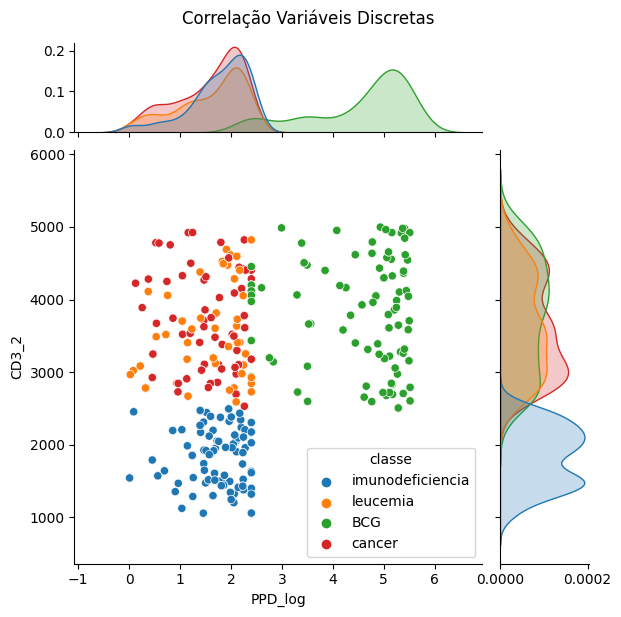

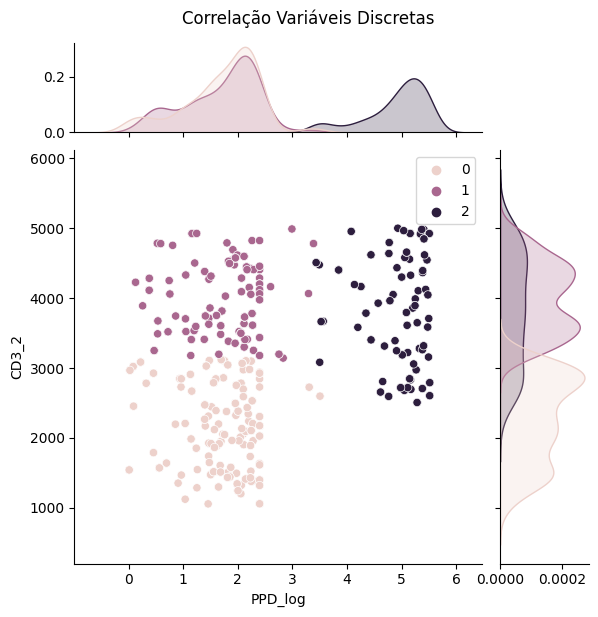

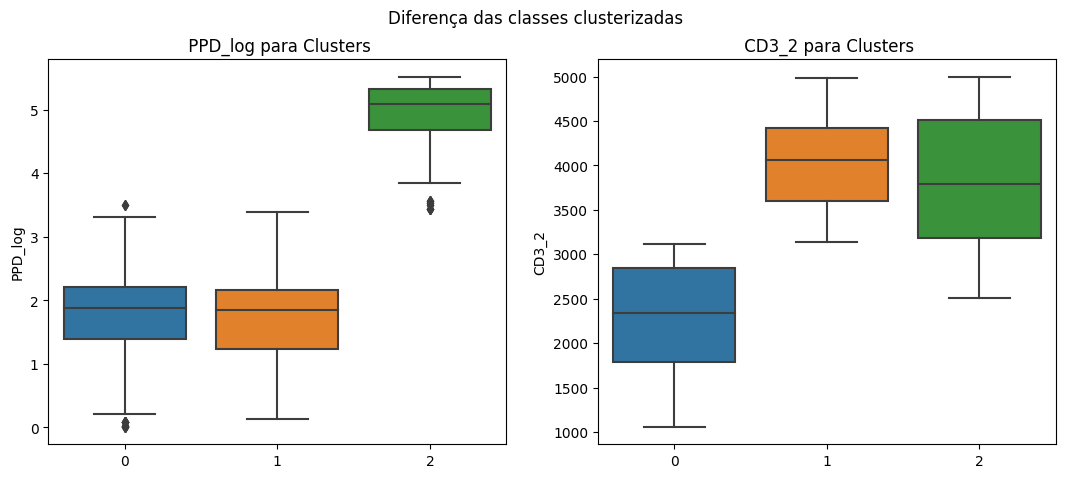

In [11]:
# Analisando os clusters para variável PPD_log e CD3_2

i = bivariadas[1][0]
j = bivariadas[1][1]
cluster = Clustering(c1=i, c2=j, df=df_train, modelo=nome_modelo)
cluster.cross_validation()

=== MELHOR CONFIGURAÇÃO ENCONTRADA VIA cross_val_score ===
Parâmetros: {'n_clusters': 3, 'init': 'k-means++', 'n_init': 10}
Silhouette Score Médio (CV): 0.4817

Silhouette Score -> 0.474
Calinski Harabasz Score -> 905.488
Davies Bouldin Score -> 0.716
Adjusted Rand Score -> 0.389
Adjusted Mutual Info Score -> 0.486


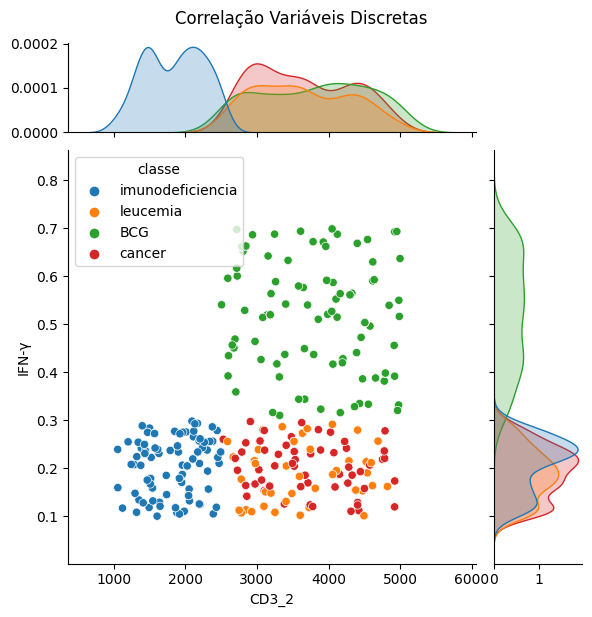

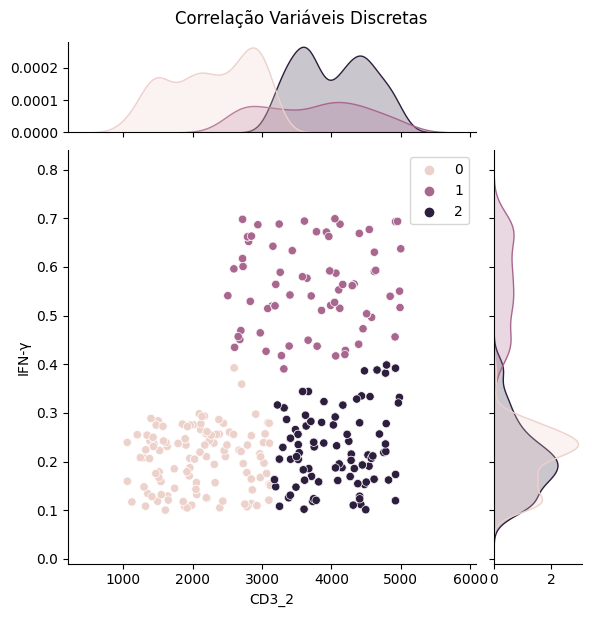

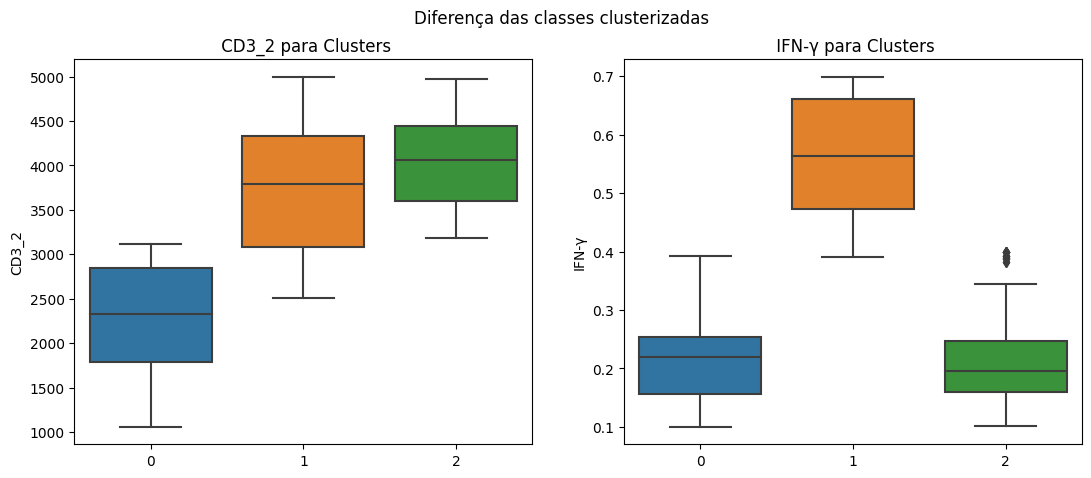

In [12]:
# Analisando os clusters para variável IFN-γ e CD3_2

i = bivariadas[2][0]
j = bivariadas[2][1]
cluster = Clustering(c1=i, c2=j, df=df_train, modelo=nome_modelo)
cluster.cross_validation()

=== MELHOR CONFIGURAÇÃO ENCONTRADA VIA cross_val_score ===
Parâmetros: {'n_clusters': 2, 'init': 'k-means++', 'n_init': 'auto'}
Silhouette Score Médio (CV): 0.7076

Silhouette Score -> 0.709
Calinski Harabasz Score -> 2214.499
Davies Bouldin Score -> 0.5
Adjusted Rand Score -> 0.325
Adjusted Mutual Info Score -> 0.545


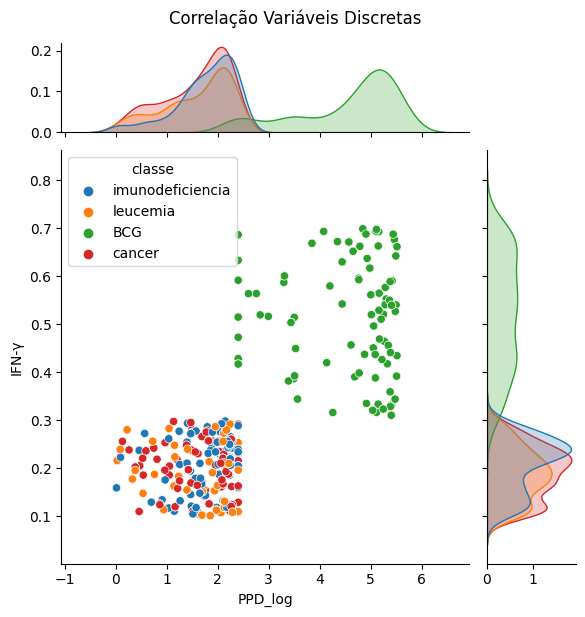

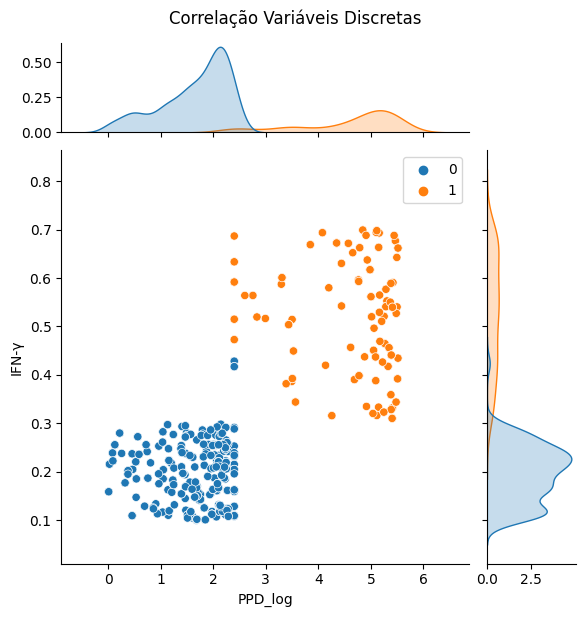

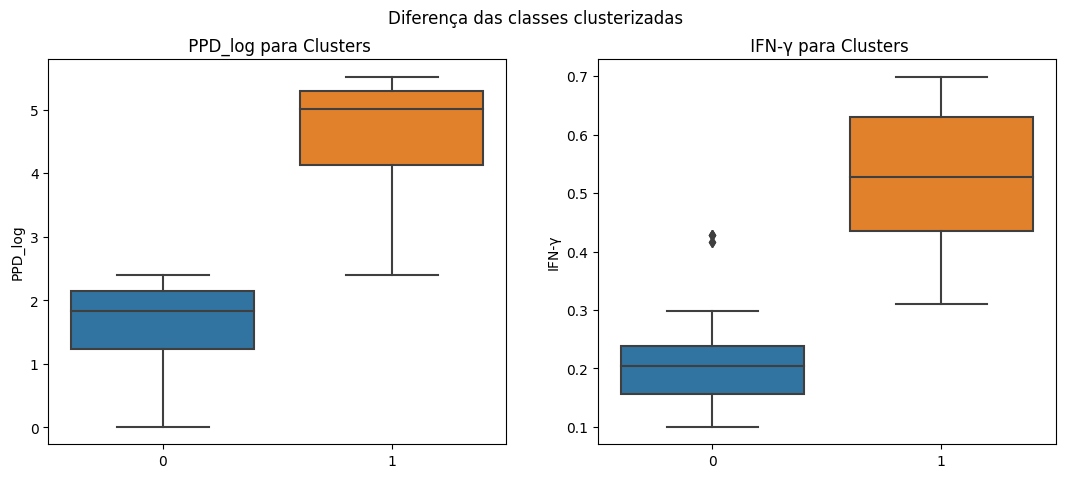

In [13]:
# Analisando os clusters para variável PPD_log e IFN-γ

i = bivariadas[0][0]
j = bivariadas[0][1]
cluster = Clustering(c1=i, c2=j, df=df_train, modelo=nome_modelo)
cluster.cross_validation()

In [14]:
# Repetindo as análises de clustering para a combinação de variáveis
# PPD_log e IFN-γ, 100 vezes, para verificar a estabilidade das métricas
# de avaliação de clustering
data = {}
for i in range(100):
    cluster = Clustering(c1="PPD_log", c2="IFN-γ", df=df_train, modelo=nome_modelo)
    _, metricas = cluster.cross_validation(print_metricas=False)
    data[i] = metricas

df_metricas_repeti = pd.DataFrame(data).T.rename(
    columns={
        0: "Silhouette",
        1: "Calinski Harabasz",
        2: "Davies Bouldin",
        3: "Adjusted Rand",
        4: "Adjusted Mutual Info",
    }
)
df_metricas_repeti.head()

,Silhouette,Calinski Harabasz,Davies Bouldin,Adjusted Rand,Adjusted Mutual Info
0,0.709,2214.499,0.5,0.325,0.545
1,0.709,2214.499,0.5,0.325,0.545
2,0.709,2214.499,0.5,0.325,0.545
3,0.709,2214.499,0.5,0.325,0.545
4,0.709,2214.499,0.5,0.325,0.545


In [15]:
# Analisando as métricas de avaliação de clustering para a combinação
# de variáveis PPD_log e IFN-γ, repetidas 100 vezes
df_metricas_repeti.describe()

,Silhouette,Calinski Harabasz,Davies Bouldin,Adjusted Rand,Adjusted Mutual Info
count,100.000,1.000000e+02,100.0,1.000000e+02,100.000
mean,0.709,2.214499e+03,0.5,3.250000e-01,0.545
std,0.000,4.570383e-13,0.0,5.579081e-17,0.000
min,0.709,2.214499e+03,0.5,3.250000e-01,0.545
25%,0.709,2.214499e+03,0.5,3.250000e-01,0.545
50%,0.709,2.214499e+03,0.5,3.250000e-01,0.545
75%,0.709,2.214499e+03,0.5,3.250000e-01,0.545
max,0.709,2.214499e+03,0.5,3.250000e-01,0.545


### Validação

In [16]:
# Importando os dados de validação
df_valid = pd.concat(
    [
        load("./data/df_estruturada/08_aula_09_X_valid"),
        load("./data/df_estruturada/08_aula_09_y_valid"),
    ],
    axis=1,
)
df_valid.head()

,TP53,IFN-γ,CD3_2,CD8,PPD_log,correlatas,IgM,classe
904,0.205760,0.185144,1735.512581,778.451959,2.228345,0.117692,Baixo,imunodeficiencia
543,0.159611,0.161689,3612.217462,903.493773,2.271285,0.411603,Alto,leucemia
139,0.103551,0.147413,3488.419699,1593.807397,0.532531,0.439125,Alto,cancer
526,0.089775,0.154566,4379.204565,948.954431,1.394407,0.332721,Alto,cancer
868,0.175694,0.205065,3249.381189,1134.132464,0.468055,0.338485,Alto,cancer


In [17]:
# Repetindo as análises de clustering para a combinação de variáveis
# PPD_log e IFN-γ, 100 vezes, para verificar a estabilidade das métricas
# de avaliação de clustering

data = {}
for i in range(100):
    cluster = Clustering(
        c1=bivariadas[0][0], c2=bivariadas[0][1], df=df_valid, modelo=nome_modelo
    )
    _, metricas = cluster.cross_validation(print_metricas=False)
    data[i] = metricas

df_metricas_repeti_valid_kmeans = pd.DataFrame(data).T.rename(
    columns={
        0: "Silhouette",
        1: "Calinski Harabasz",
        2: "Davies Bouldin",
        3: "Adjusted Rand",
        4: "Adjusted Mutual Info",
    }
)
df_metricas_repeti_valid_kmeans.head()

,Silhouette,Calinski Harabasz,Davies Bouldin,Adjusted Rand,Adjusted Mutual Info
0,0.714,660.094,0.484,0.341,0.561
1,0.714,660.094,0.484,0.341,0.561
2,0.714,660.094,0.484,0.341,0.561
3,0.714,660.094,0.484,0.341,0.561
4,0.714,660.094,0.484,0.341,0.561


In [18]:
# Analisando as métricas de avaliação de clustering para a combinação
# de variáveis PPD_log e IFN-γ, repetidas 100 vezes
df_metricas_repeti_valid_kmeans.describe()

,Silhouette,Calinski Harabasz,Davies Bouldin,Adjusted Rand,Adjusted Mutual Info
count,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02,100.000
mean,7.140000e-01,6.600940e+02,4.840000e-01,3.410000e-01,0.561
std,1.115816e-16,1.142596e-13,5.579081e-17,1.115816e-16,0.000
min,7.140000e-01,6.600940e+02,4.840000e-01,3.410000e-01,0.561
25%,7.140000e-01,6.600940e+02,4.840000e-01,3.410000e-01,0.561
50%,7.140000e-01,6.600940e+02,4.840000e-01,3.410000e-01,0.561
75%,7.140000e-01,6.600940e+02,4.840000e-01,3.410000e-01,0.561
max,7.140000e-01,6.600940e+02,4.840000e-01,3.410000e-01,0.561


=== MELHOR CONFIGURAÇÃO ENCONTRADA VIA cross_val_score ===
Parâmetros: {'n_clusters': 3, 'init': 'k-means++', 'n_init': 10}
Silhouette Score Médio (CV): 0.4959

Silhouette Score -> 0.485
Calinski Harabasz Score -> 260.265
Davies Bouldin Score -> 0.712
Adjusted Rand Score -> 0.426
Adjusted Mutual Info Score -> 0.505


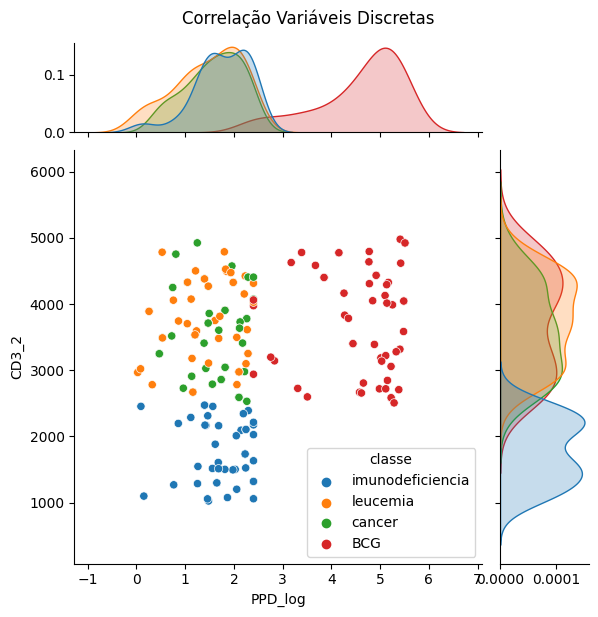

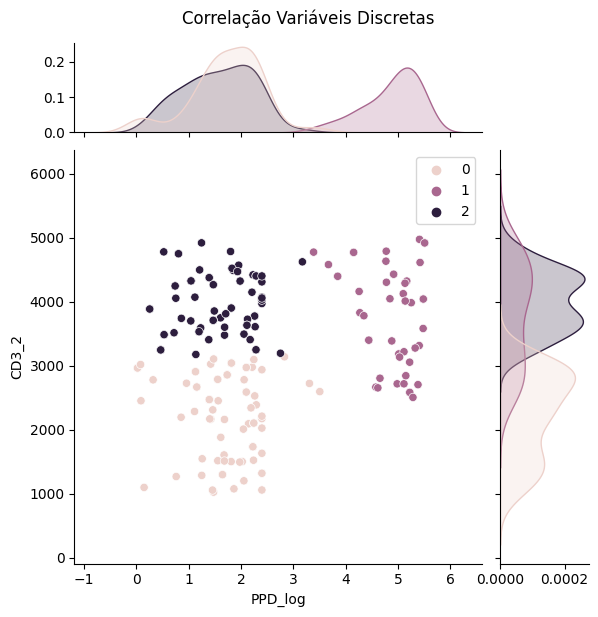

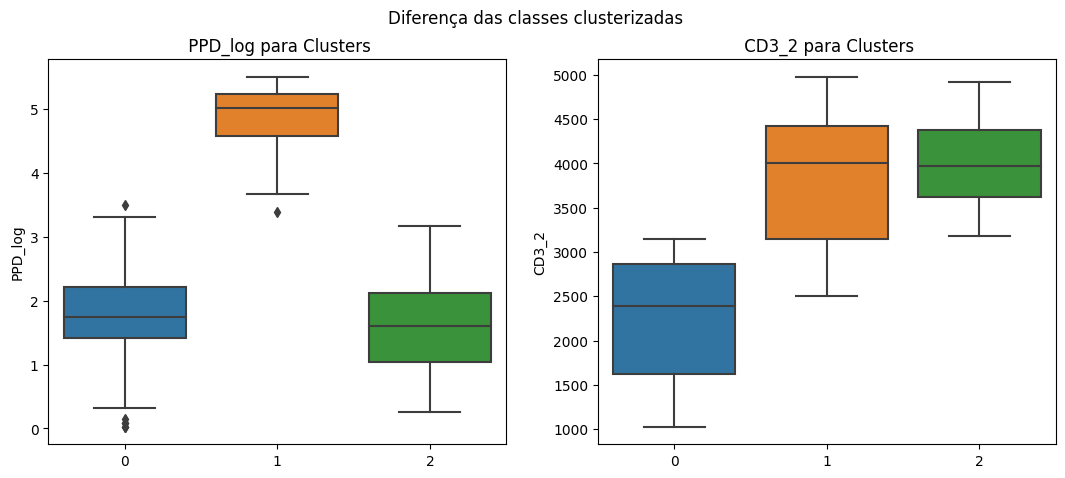

In [19]:
# Analisando os clusters para variável PPD_log e CD3_2

cluster = Clustering(
    c1=bivariadas[1][0], c2=bivariadas[1][1], df=df_valid, modelo=nome_modelo
)
cluster.cross_validation()

=== MELHOR CONFIGURAÇÃO ENCONTRADA VIA cross_val_score ===
Parâmetros: {'n_clusters': 3, 'init': 'random', 'n_init': 'auto'}
Silhouette Score Médio (CV): 0.4790

Silhouette Score -> 0.478
Calinski Harabasz Score -> 253.903
Davies Bouldin Score -> 0.704
Adjusted Rand Score -> 0.338
Adjusted Mutual Info Score -> 0.432


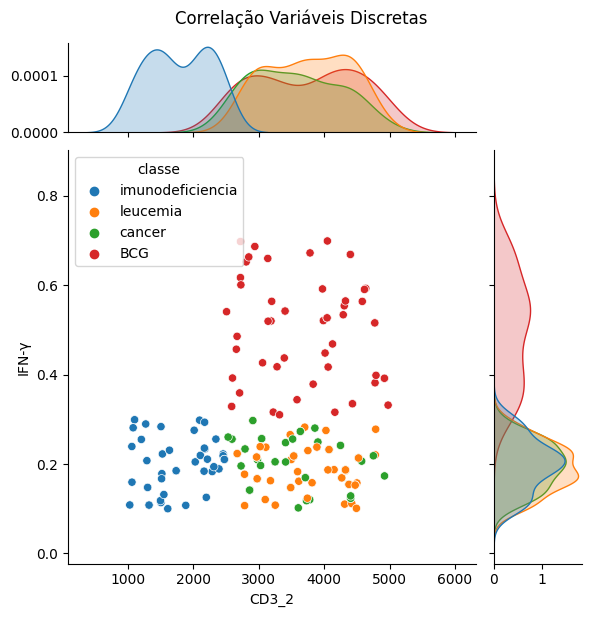

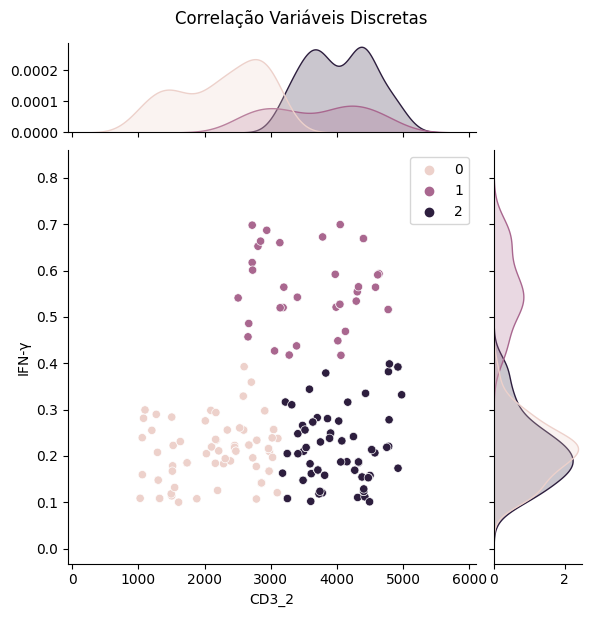

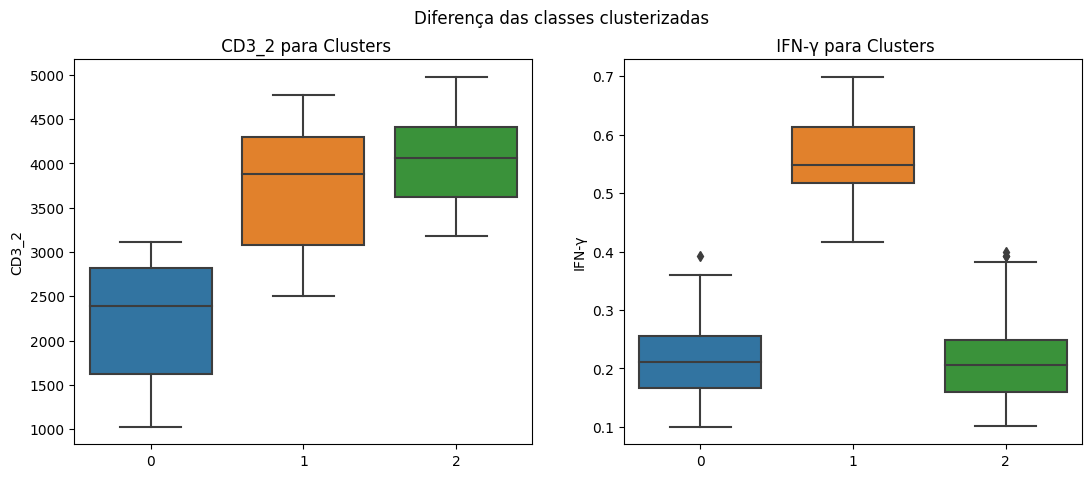

In [20]:
# Analisando os clusters para variável IFN-γ e CD3_2

cluster = Clustering(
    c1=bivariadas[2][0], c2=bivariadas[2][1], df=df_valid, modelo=nome_modelo
)
cluster.cross_validation()

=== MELHOR CONFIGURAÇÃO ENCONTRADA VIA cross_val_score ===
Parâmetros: {'n_clusters': 2, 'init': 'k-means++', 'n_init': 'auto'}
Silhouette Score Médio (CV): 0.7085

Silhouette Score -> 0.714
Calinski Harabasz Score -> 660.094
Davies Bouldin Score -> 0.484
Adjusted Rand Score -> 0.341
Adjusted Mutual Info Score -> 0.561


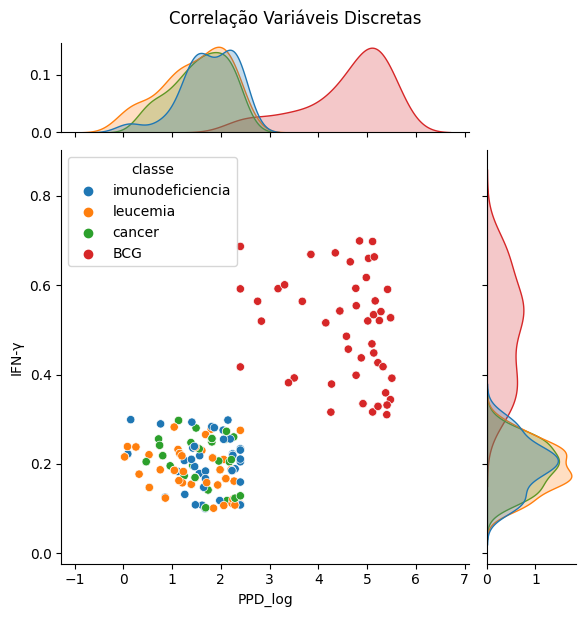

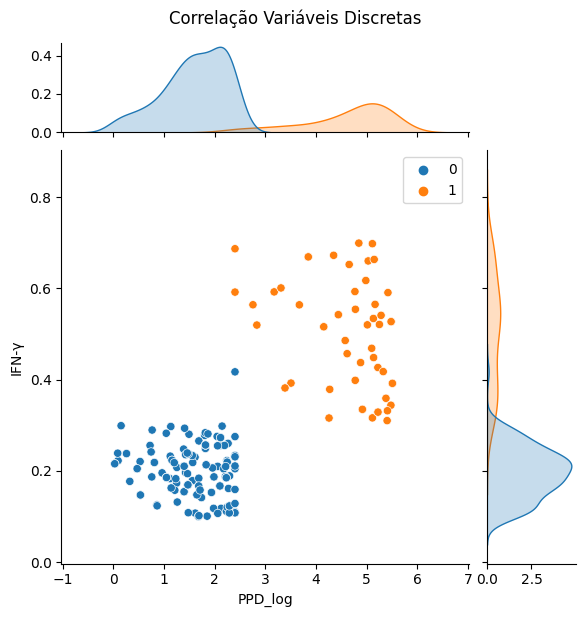

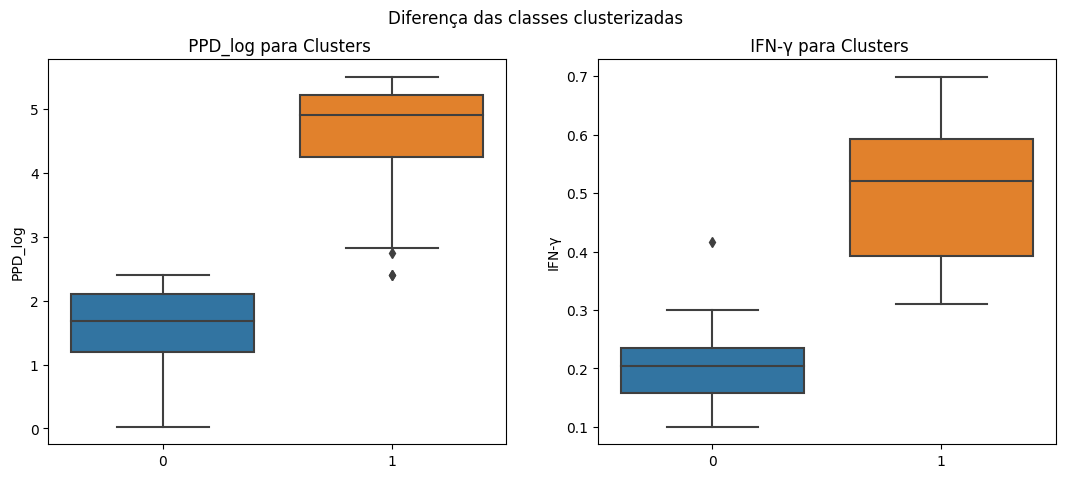

In [21]:
# Analisando os clusters para variável PPD_log e IFN-γ

cluster = Clustering(
    c1=bivariadas[0][0], c2=bivariadas[0][1], df=df_valid, modelo=nome_modelo
)
cluster.cross_validation()

## DBSCAN

### Treino

In [22]:
# Definindo um objeto de clustering com os dados de treino
nome_modelo = "dbscan"
cluster = Clustering(
    c1=bivariadas[0][0], c2=bivariadas[0][1], df=df_train, modelo=nome_modelo
)
cluster.cross_validation(print_metricas=False)[0][:5]

array([0, 0, 0, 0, 0])

In [23]:
# Obtendo as métricas de avaliação de clustering para todas as combinações de
# variáveis
data = {}
for i in df_train.columns[:-2]:
    for j in df_train.columns[:-2]:
        if i != j:
            cluster = Clustering(c1=i, c2=j, df=df_train, modelo=nome_modelo)
            _, metricas = cluster.cross_validation(print_metricas=False)
            data[i + "_" + j] = metricas
df_metricas = pd.DataFrame(data).T.rename(
    columns={
        0: "Silhouette",
        1: "Calinski Harabasz",
        2: "Davies Bouldin",
        3: "Adjusted Rand",
        4: "Adjusted Mutual Info",
    }
)
df_metricas.head()

,Silhouette,Calinski Harabasz,Davies Bouldin,Adjusted Rand,Adjusted Mutual Info
TP53_IFN-γ,0.028,81.948,1.185,0.026,0.144
TP53_CD3_2,NaN,NaN,NaN,NaN,NaN
TP53_CD8,NaN,NaN,NaN,NaN,NaN
TP53_PPD_log,0.072,7.295,2.116,-0.000,0.014
TP53_correlatas,0.109,254.457,1.275,0.104,0.257


In [24]:
# Selecionando as melhores combinações de variáveis com base nas métricas de
# avaliação de clustering
display(df_metricas["Silhouette"].nlargest(1))
display(df_metricas["Calinski Harabasz"].nsmallest(1))
display(df_metricas["Davies Bouldin"].nlargest(1))
display(df_metricas["Adjusted Rand"].nlargest(1))
display(df_metricas["Adjusted Mutual Info"].nlargest(1))

IFN-γ_PPD_log    0.529
Name: Silhouette, dtype: float64

CD3_2_PPD_log    2.318
Name: Calinski Harabasz, dtype: float64

PPD_log_correlatas    2.671
Name: Davies Bouldin, dtype: float64

IFN-γ_PPD_log    0.289
Name: Adjusted Rand, dtype: float64

IFN-γ_PPD_log    0.537
Name: Adjusted Mutual Info, dtype: float64

=== MELHOR CONFIGURAÇÃO ENCONTRADA VIA cross_val_score ===
Parâmetros: {'eps': 0.5, 'min_samples': 10, 'metric': 'euclidean'}
Silhouette Score Médio (CV): 0.2787

Silhouette Score -> -0.096
Calinski Harabasz Score -> 2.318
Davies Bouldin Score -> 1.535
Adjusted Rand Score -> -0.0
Adjusted Mutual Info Score -> 0.013


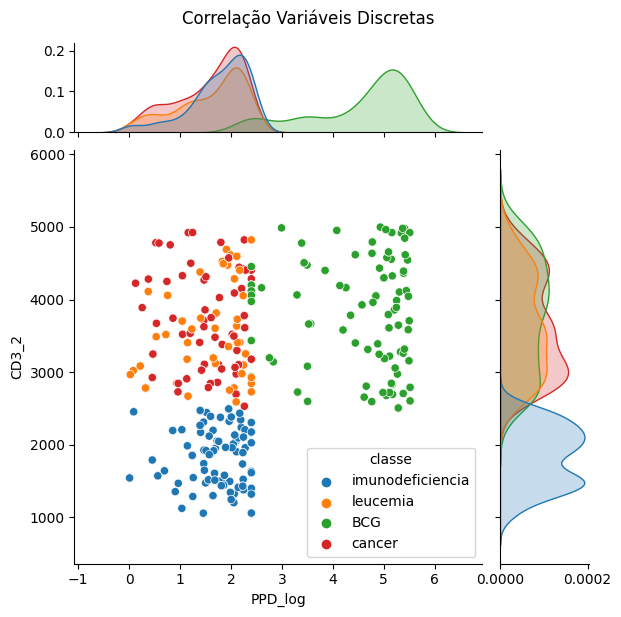

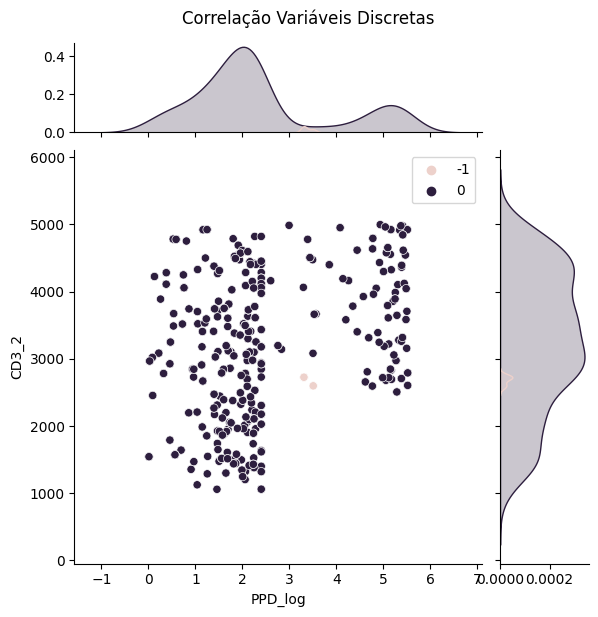

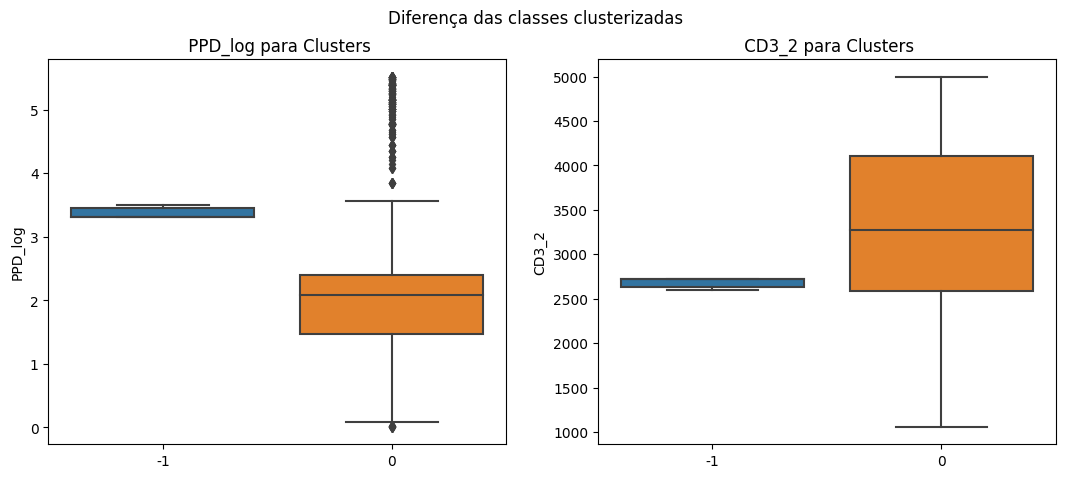

In [25]:
# Analisando os clusters para variável PPD_log e CD3_2

i = bivariadas[1][0]
j = bivariadas[1][1]
cluster = Clustering(c1=i, c2=j, df=df_train, modelo=nome_modelo)
cluster.cross_validation()

=== MELHOR CONFIGURAÇÃO ENCONTRADA VIA cross_val_score ===
Parâmetros: {'eps': 0.5, 'min_samples': 10, 'metric': 'euclidean'}
Silhouette Score Médio (CV): 0.4590

Silhouette Score -> nan
Calinski Harabasz Score -> nan
Davies Bouldin Score -> nan
Adjusted Rand Score -> nan
Adjusted Mutual Info Score -> nan


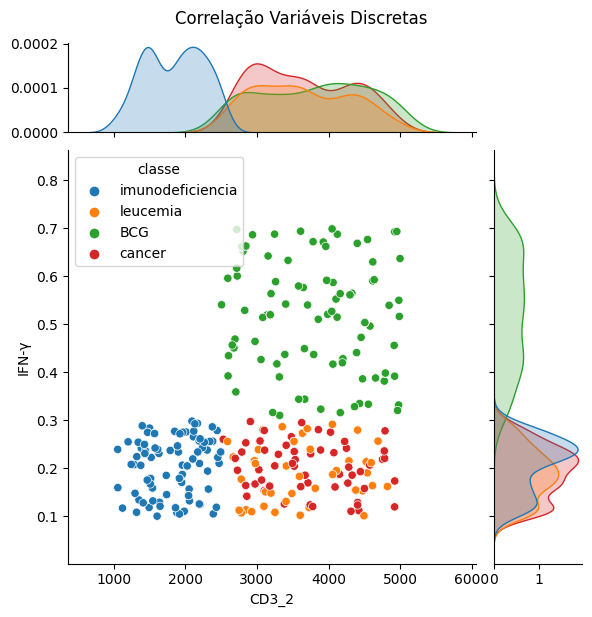

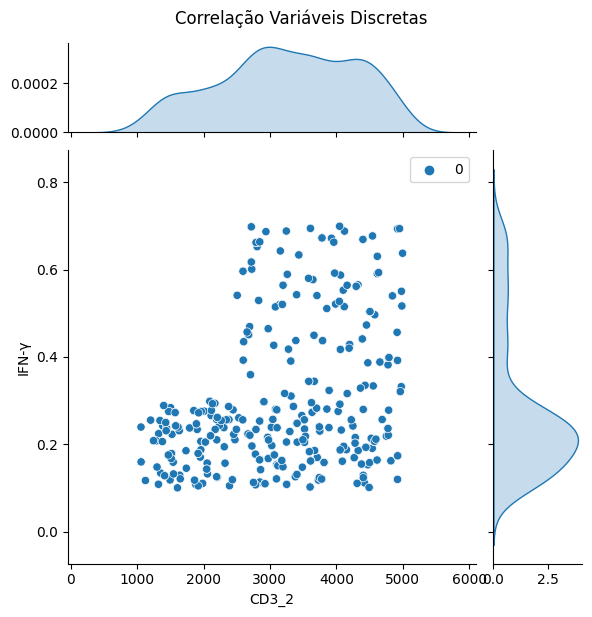

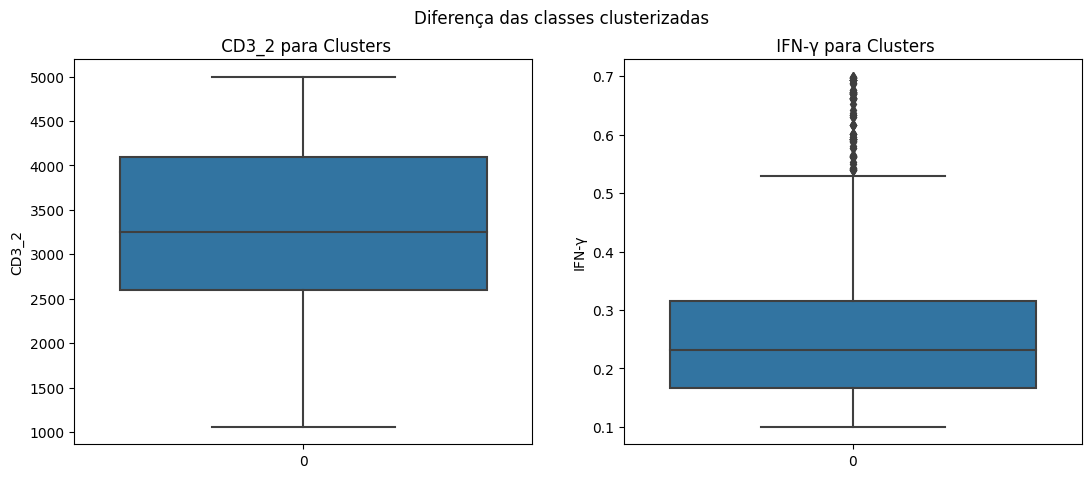

In [26]:
# Analisando os clusters para variável IFN-γ e CD3_2

i = bivariadas[2][0]
j = bivariadas[2][1]
cluster = Clustering(c1=i, c2=j, df=df_train, modelo=nome_modelo)
cluster.cross_validation()

=== MELHOR CONFIGURAÇÃO ENCONTRADA VIA cross_val_score ===
Parâmetros: {'eps': 0.5, 'min_samples': 15, 'metric': 'euclidean'}
Silhouette Score Médio (CV): 0.7007

Silhouette Score -> 0.529
Calinski Harabasz Score -> 976.06
Davies Bouldin Score -> 0.944
Adjusted Rand Score -> 0.289
Adjusted Mutual Info Score -> 0.537


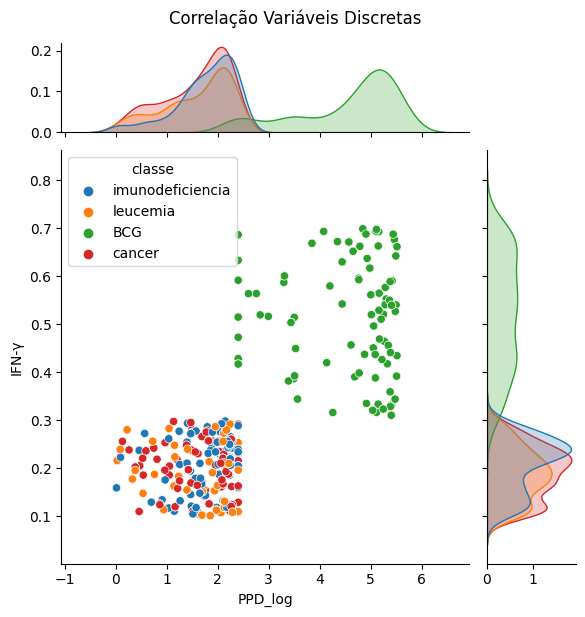

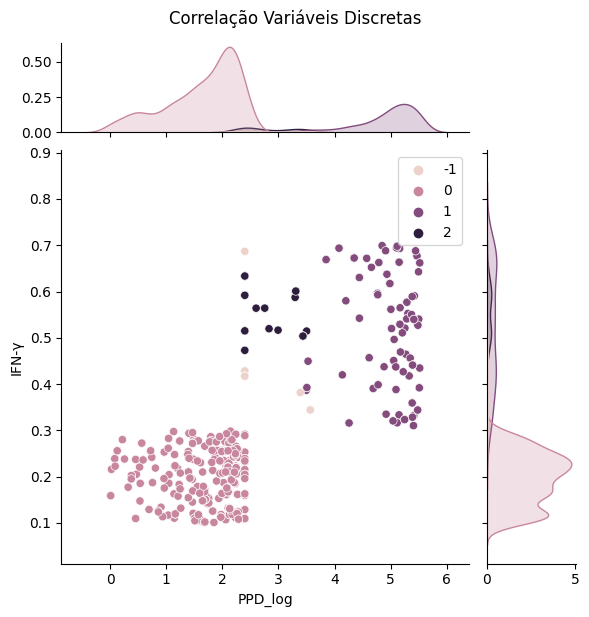

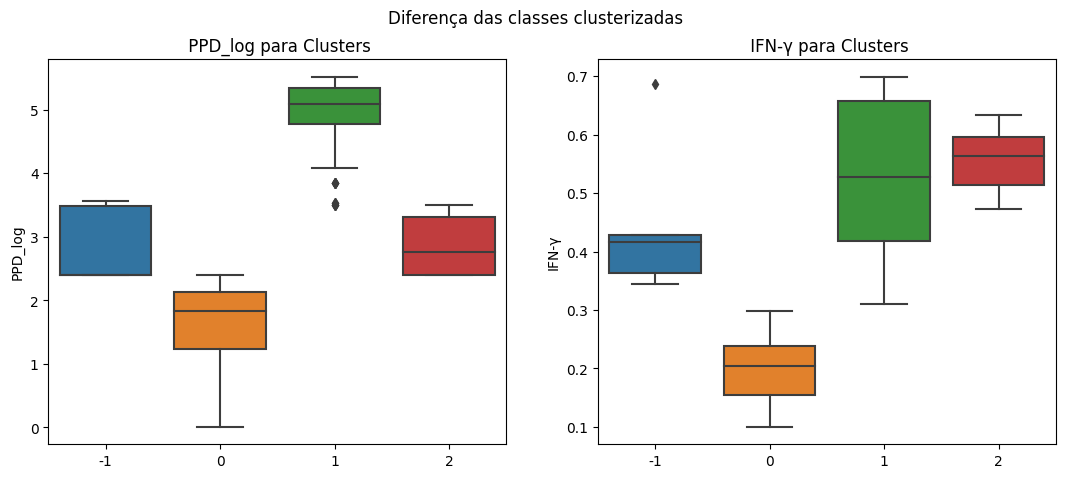

In [27]:
# Analisando os clusters para variável PPD_log e IFN-γ

i = bivariadas[0][0]
j = bivariadas[0][1]
cluster = Clustering(c1=i, c2=j, df=df_train, modelo=nome_modelo)
cluster.cross_validation()

In [28]:
# Repetindo as análises de clustering para a combinação de variáveis
# PPD_log e IFN-γ, 100 vezes, para verificar a estabilidade das métricas
# de avaliação de clustering
data = {}
for i in range(100):
    cluster = Clustering(c1="PPD_log", c2="IFN-γ", df=df_train, modelo=nome_modelo)
    _, metricas = cluster.cross_validation(print_metricas=False)
    data[i] = metricas

df_metricas_repeti = pd.DataFrame(data).T.rename(
    columns={
        0: "Silhouette",
        1: "Calinski Harabasz",
        2: "Davies Bouldin",
        3: "Adjusted Rand",
        4: "Adjusted Mutual Info",
    }
)
df_metricas_repeti.head()

,Silhouette,Calinski Harabasz,Davies Bouldin,Adjusted Rand,Adjusted Mutual Info
0,0.529,976.06,0.944,0.289,0.537
1,0.529,976.06,0.944,0.289,0.537
2,0.529,976.06,0.944,0.289,0.537
3,0.529,976.06,0.944,0.289,0.537
4,0.529,976.06,0.944,0.289,0.537


In [29]:
# Analisando as métricas de avaliação de clustering para a combinação
# de variáveis PPD_log e IFN-γ, repetidas 100 vezes
df_metricas_repeti.describe()

,Silhouette,Calinski Harabasz,Davies Bouldin,Adjusted Rand,Adjusted Mutual Info
count,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02
mean,5.290000e-01,9.760600e+02,9.440000e-01,2.890000e-01,5.370000e-01
std,1.115816e-16,3.427787e-13,2.231632e-16,1.115816e-16,1.115816e-16
min,5.290000e-01,9.760600e+02,9.440000e-01,2.890000e-01,5.370000e-01
25%,5.290000e-01,9.760600e+02,9.440000e-01,2.890000e-01,5.370000e-01
50%,5.290000e-01,9.760600e+02,9.440000e-01,2.890000e-01,5.370000e-01
75%,5.290000e-01,9.760600e+02,9.440000e-01,2.890000e-01,5.370000e-01
max,5.290000e-01,9.760600e+02,9.440000e-01,2.890000e-01,5.370000e-01


### Validação

In [30]:
# Importando os dados de validação
df_valid = pd.concat(
    [
        load("./data/df_estruturada/08_aula_09_X_valid"),
        load("./data/df_estruturada/08_aula_09_y_valid"),
    ],
    axis=1,
)
df_valid.head()

,TP53,IFN-γ,CD3_2,CD8,PPD_log,correlatas,IgM,classe
904,0.205760,0.185144,1735.512581,778.451959,2.228345,0.117692,Baixo,imunodeficiencia
543,0.159611,0.161689,3612.217462,903.493773,2.271285,0.411603,Alto,leucemia
139,0.103551,0.147413,3488.419699,1593.807397,0.532531,0.439125,Alto,cancer
526,0.089775,0.154566,4379.204565,948.954431,1.394407,0.332721,Alto,cancer
868,0.175694,0.205065,3249.381189,1134.132464,0.468055,0.338485,Alto,cancer


In [31]:
# Repetindo as análises de clustering para a combinação de variáveis
# PPD_log e IFN-γ, 100 vezes, para verificar a estabilidade das métricas
# de avaliação de clustering
data = {}
for i in range(100):
    cluster = Clustering(
        c1=bivariadas[0][0], c2=bivariadas[0][1], df=df_valid, modelo=nome_modelo
    )
    _, metricas = cluster.cross_validation(print_metricas=False)
    data[i] = metricas

df_metricas_repeti_valid_dbscan = pd.DataFrame(data).T.rename(
    columns={
        0: "Silhouette",
        1: "Calinski Harabasz",
        2: "Davies Bouldin",
        3: "Adjusted Rand",
        4: "Adjusted Mutual Info",
    }
)
df_metricas_repeti_valid_dbscan.head()

,Silhouette,Calinski Harabasz,Davies Bouldin,Adjusted Rand,Adjusted Mutual Info
0,0.652,429.181,0.931,0.281,0.541
1,0.652,429.181,0.931,0.281,0.541
2,0.652,429.181,0.931,0.281,0.541
3,0.652,429.181,0.931,0.281,0.541
4,0.652,429.181,0.931,0.281,0.541


In [32]:
# Analisando as métricas de avaliação de clustering para a combinação
# de variáveis PPD_log e IFN-γ, repetidas 100 vezes
df_metricas_repeti_valid_dbscan.describe()

,Silhouette,Calinski Harabasz,Davies Bouldin,Adjusted Rand,Adjusted Mutual Info
count,100.000,1.000000e+02,1.000000e+02,100.000,100.000
mean,0.652,4.291810e+02,9.310000e-01,0.281,0.541
std,0.000,2.285191e-13,2.231632e-16,0.000,0.000
min,0.652,4.291810e+02,9.310000e-01,0.281,0.541
25%,0.652,4.291810e+02,9.310000e-01,0.281,0.541
50%,0.652,4.291810e+02,9.310000e-01,0.281,0.541
75%,0.652,4.291810e+02,9.310000e-01,0.281,0.541
max,0.652,4.291810e+02,9.310000e-01,0.281,0.541


=== MELHOR CONFIGURAÇÃO ENCONTRADA VIA cross_val_score ===
Parâmetros: {'eps': 0.5, 'min_samples': 3, 'metric': 'euclidean'}
Silhouette Score Médio (CV): 0.3682

Silhouette Score -> 0.165
Calinski Harabasz Score -> 83.659
Davies Bouldin Score -> 0.826
Adjusted Rand Score -> 0.272
Adjusted Mutual Info Score -> 0.469


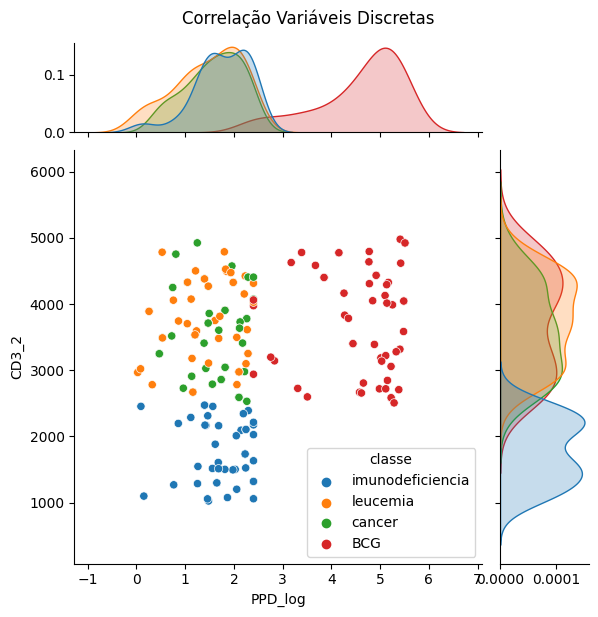

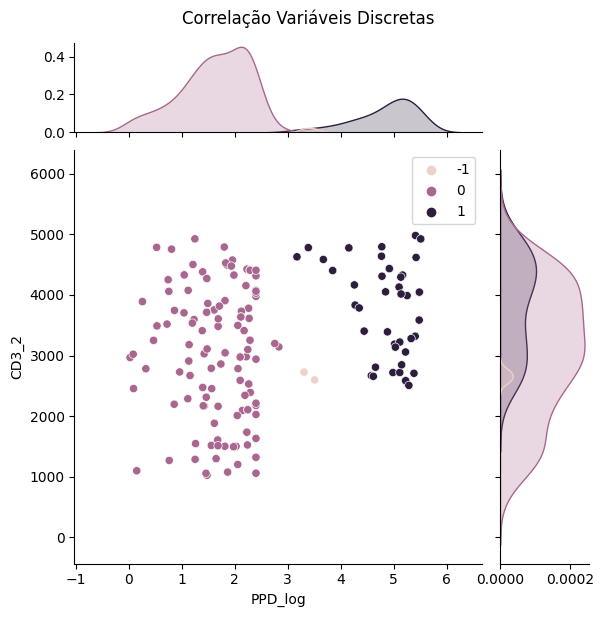

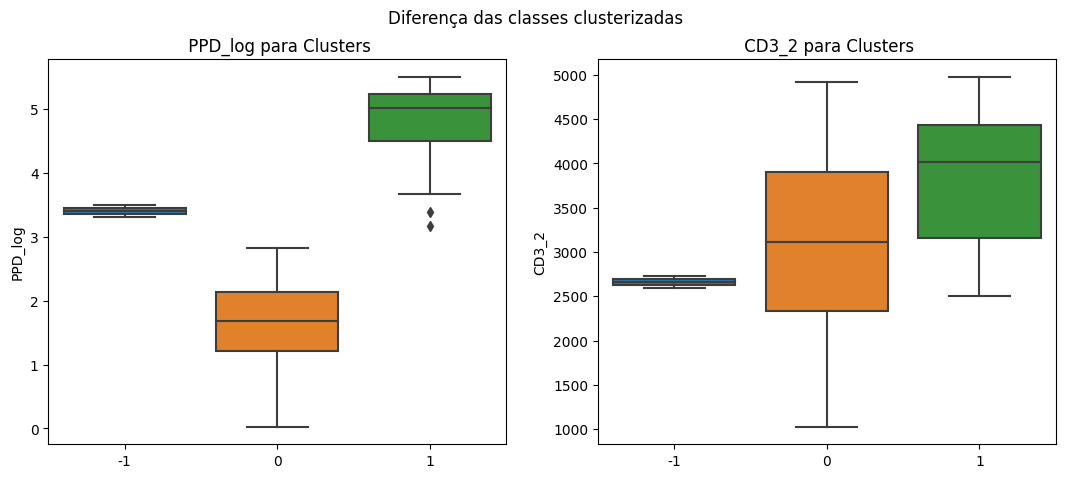

In [33]:
# Analisando os clusters para variável PPD_log e CD3_2

cluster = Clustering(
    c1=bivariadas[1][0], c2=bivariadas[1][1], df=df_valid, modelo=nome_modelo
)
cluster.cross_validation()

=== MELHOR CONFIGURAÇÃO ENCONTRADA VIA cross_val_score ===
Parâmetros: {'eps': 0.5, 'min_samples': 3, 'metric': 'euclidean'}
Silhouette Score Médio (CV): 0.3635

Silhouette Score -> 0.204
Calinski Harabasz Score -> 12.813
Davies Bouldin Score -> 0.679
Adjusted Rand Score -> 0.001
Adjusted Mutual Info Score -> 0.055


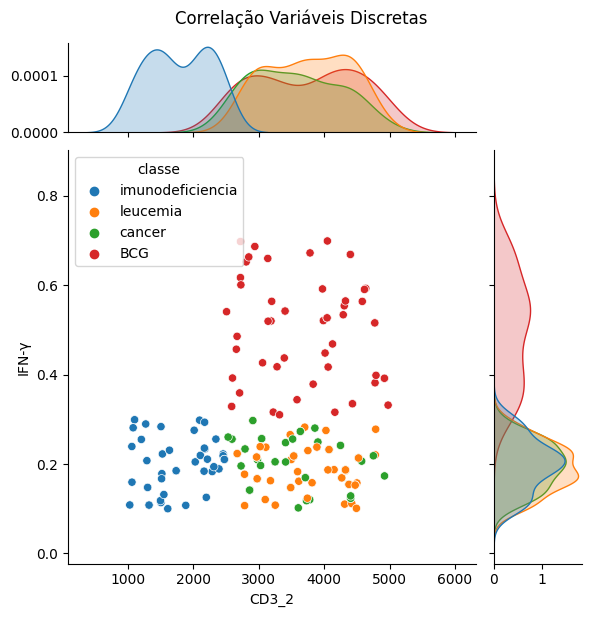

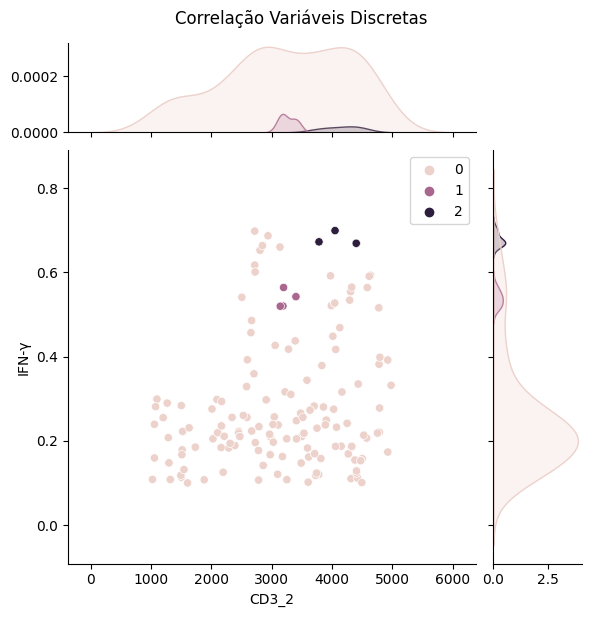

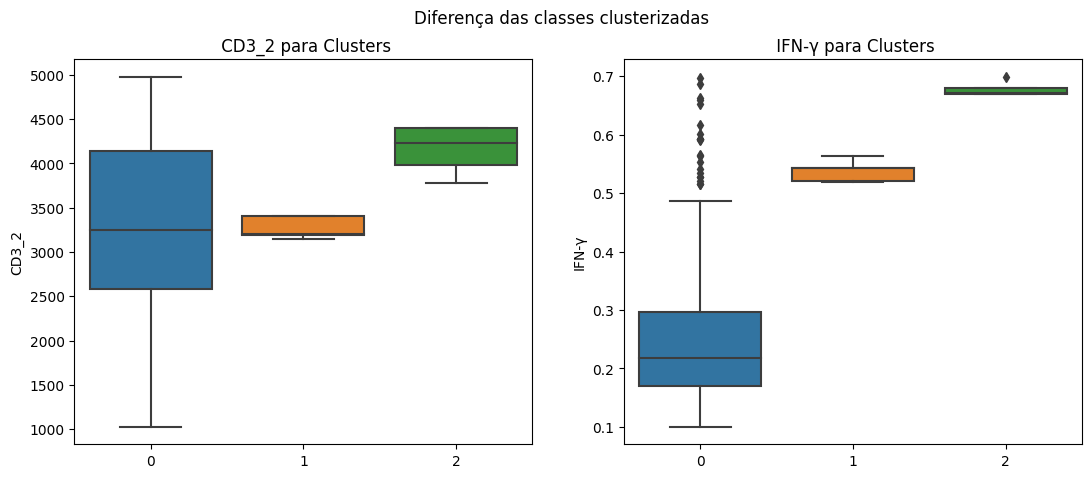

In [34]:
# Analisando os clusters para variável IFN-γ e CD3_2

cluster = Clustering(
    c1=bivariadas[2][0], c2=bivariadas[2][1], df=df_valid, modelo=nome_modelo
)
cluster.cross_validation()

=== MELHOR CONFIGURAÇÃO ENCONTRADA VIA cross_val_score ===
Parâmetros: {'eps': 0.5, 'min_samples': 10, 'metric': 'euclidean'}
Silhouette Score Médio (CV): 0.6334

Silhouette Score -> 0.652
Calinski Harabasz Score -> 429.181
Davies Bouldin Score -> 0.931
Adjusted Rand Score -> 0.281
Adjusted Mutual Info Score -> 0.541


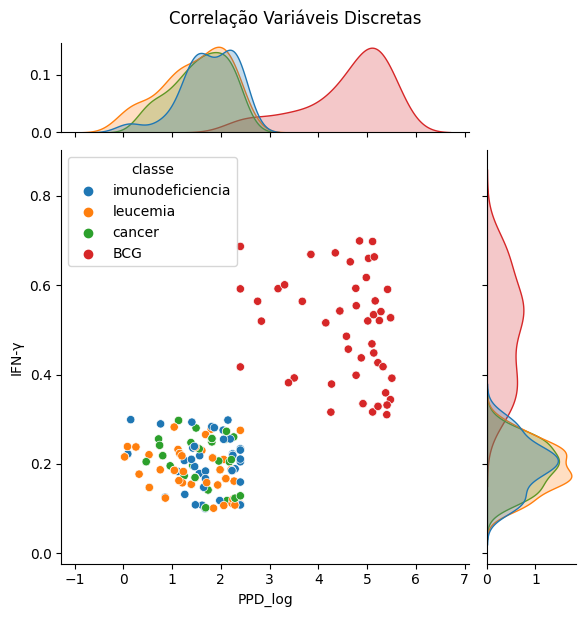

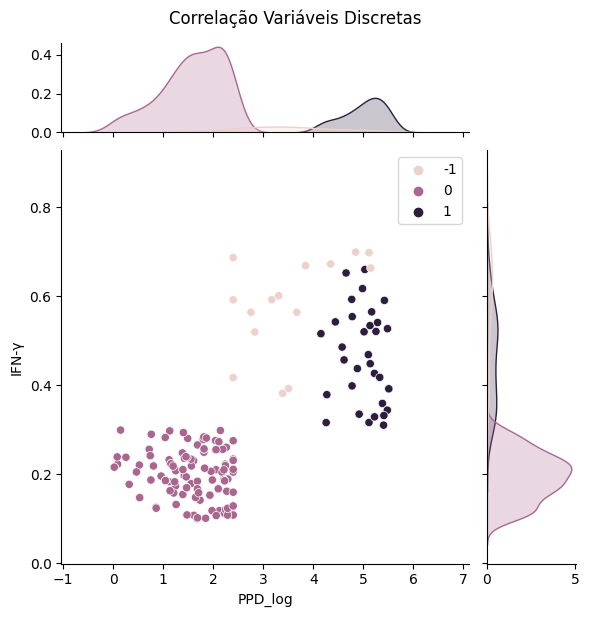

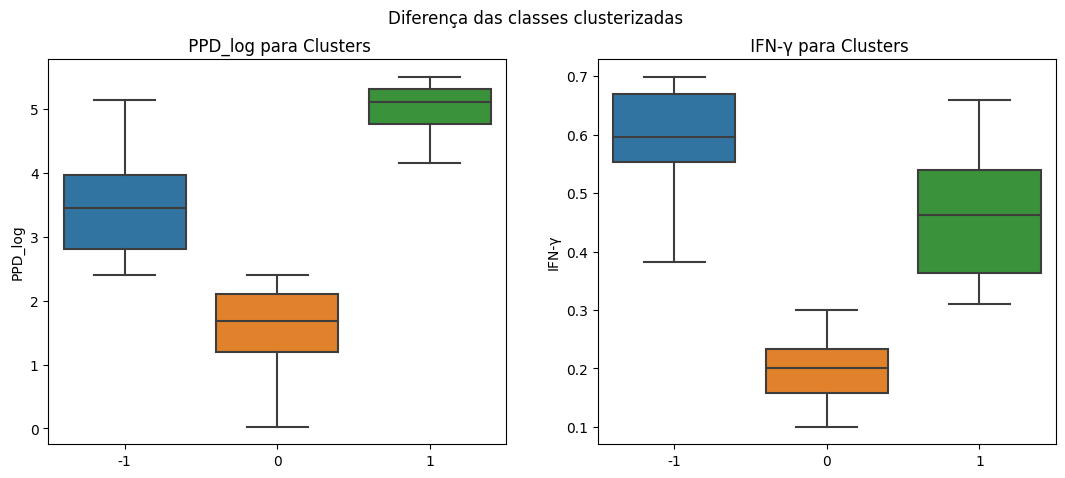

In [35]:
# Analisando os clusters para variável PPD_log e IFN-γ
cluster = Clustering(
    c1=bivariadas[0][0], c2=bivariadas[0][1], df=df_valid, modelo=nome_modelo
)
cluster.cross_validation()

## Agrupamento Hierarquico

### Treino

In [36]:
param_combinations = [
    {"n_clusters": k, "linkage": "ward", "metric": "euclidean"} for k in [2, 3, 4, 5, 6]
] + [
    {"n_clusters": k, "linkage": linkage, "metric": metric}
    for k in [2, 3, 4, 5, 6]
    for linkage in ["complete", "average", "single"]
    for metric in ["euclidean", "manhattan", "cosine"]
]
param_combinations

[{'n_clusters': 2, 'linkage': 'ward', 'metric': 'euclidean'},
 {'n_clusters': 3, 'linkage': 'ward', 'metric': 'euclidean'},
 {'n_clusters': 4, 'linkage': 'ward', 'metric': 'euclidean'},
 {'n_clusters': 5, 'linkage': 'ward', 'metric': 'euclidean'},
 {'n_clusters': 6, 'linkage': 'ward', 'metric': 'euclidean'},
 {'n_clusters': 2, 'linkage': 'complete', 'metric': 'euclidean'},
 {'n_clusters': 2, 'linkage': 'complete', 'metric': 'manhattan'},
 {'n_clusters': 2, 'linkage': 'complete', 'metric': 'cosine'},
 {'n_clusters': 2, 'linkage': 'average', 'metric': 'euclidean'},
 {'n_clusters': 2, 'linkage': 'average', 'metric': 'manhattan'},
 {'n_clusters': 2, 'linkage': 'average', 'metric': 'cosine'},
 {'n_clusters': 2, 'linkage': 'single', 'metric': 'euclidean'},
 {'n_clusters': 2, 'linkage': 'single', 'metric': 'manhattan'},
 {'n_clusters': 2, 'linkage': 'single', 'metric': 'cosine'},
 {'n_clusters': 3, 'linkage': 'complete', 'metric': 'euclidean'},
 {'n_clusters': 3, 'linkage': 'complete', 'metri

In [37]:
nome_modelo = "agglomerative"
cluster = Clustering(
    c1=bivariadas[0][0], c2=bivariadas[0][1], df=df_train, modelo=nome_modelo
)
cluster.cross_validation(print_metricas=False)[0][:5]

array([0, 0, 0, 0, 0])

In [38]:
# Obtendo as métricas de avaliação de clustering para todas as combinações de
# variáveis
data = {}
for i in df_train.columns[:-2]:
    for j in df_train.columns[:-2]:
        if i != j:
            cluster = Clustering(c1=i, c2=j, df=df_train, modelo=nome_modelo)
            _, metricas = cluster.cross_validation(print_metricas=False)
            data[i + "_" + j] = metricas
df_metricas = pd.DataFrame(data).T.rename(
    columns={
        0: "Silhouette",
        1: "Calinski Harabasz",
        2: "Davies Bouldin",
        3: "Adjusted Rand",
        4: "Adjusted Mutual Info",
    }
)
df_metricas.head()

,Silhouette,Calinski Harabasz,Davies Bouldin,Adjusted Rand,Adjusted Mutual Info
TP53_IFN-γ,0.492,811.709,0.723,0.193,0.346
TP53_CD3_2,0.400,565.069,0.739,0.134,0.184
TP53_CD8,0.395,552.063,0.824,0.196,0.282
TP53_PPD_log,0.505,815.445,0.682,0.188,0.350
TP53_correlatas,0.389,585.855,0.757,0.298,0.400


In [39]:
# Selecionando as melhores combinações de variáveis com base nas métricas de
# avaliação de clustering
display(df_metricas["Silhouette"].nlargest(1))
display(df_metricas["Calinski Harabasz"].nsmallest(1))
display(df_metricas["Davies Bouldin"].nlargest(1))
display(df_metricas["Adjusted Rand"].nlargest(1))
display(df_metricas["Adjusted Mutual Info"].nlargest(1))

IFN-γ_PPD_log    0.706
Name: Silhouette, dtype: float64

TP53_CD8    552.063
Name: Calinski Harabasz, dtype: float64

IFN-γ_CD3_2    0.846
Name: Davies Bouldin, dtype: float64

IFN-γ_correlatas    0.618
Name: Adjusted Rand, dtype: float64

IFN-γ_correlatas    0.714
Name: Adjusted Mutual Info, dtype: float64

=== MELHOR CONFIGURAÇÃO ENCONTRADA VIA cross_val_score ===
Parâmetros: {'n_clusters': 2, 'metric': 'euclidean', 'linkage': 'average'}
Silhouette Score Médio (CV): 0.4809

Silhouette Score -> 0.482
Calinski Harabasz Score -> 553.519
Davies Bouldin Score -> 0.804
Adjusted Rand Score -> 0.258
Adjusted Mutual Info Score -> 0.458


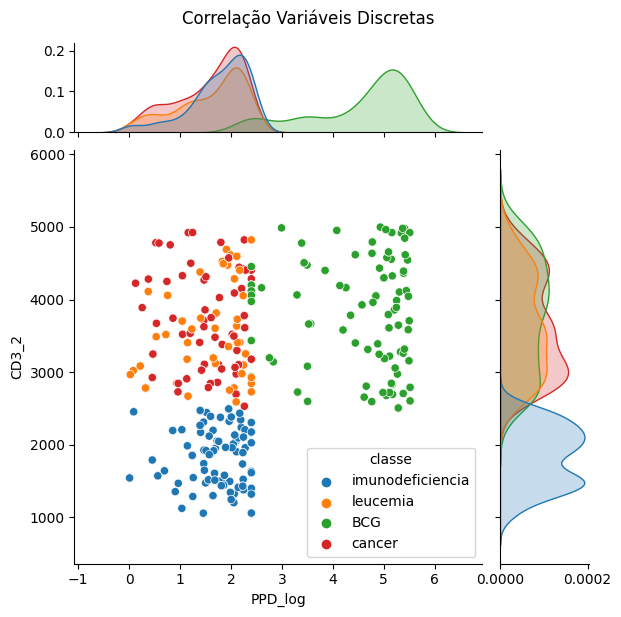

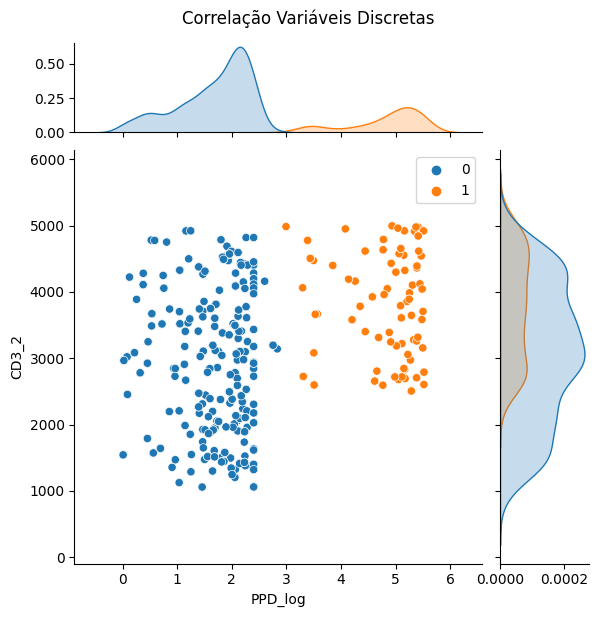

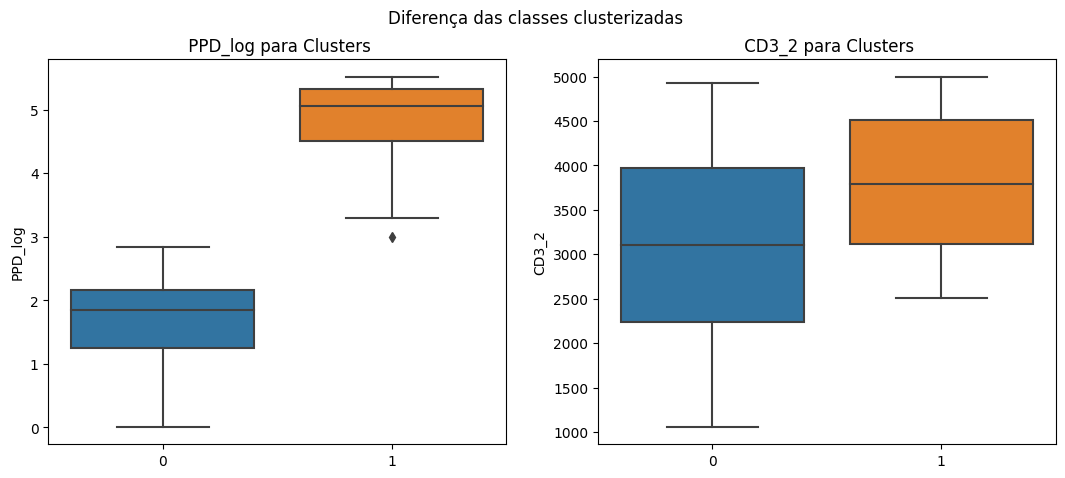

In [40]:
# Analisando os clusters para variável PPD_log e CD3_2

i = bivariadas[1][0]
j = bivariadas[1][1]
cluster = Clustering(c1=i, c2=j, df=df_train, modelo=nome_modelo)
cluster.cross_validation()

=== MELHOR CONFIGURAÇÃO ENCONTRADA VIA cross_val_score ===
Parâmetros: {'n_clusters': 2, 'metric': 'euclidean', 'linkage': 'average'}
Silhouette Score Médio (CV): 0.4726

Silhouette Score -> 0.478
Calinski Harabasz Score -> 557.646
Davies Bouldin Score -> 0.846
Adjusted Rand Score -> 0.277
Adjusted Mutual Info Score -> 0.481


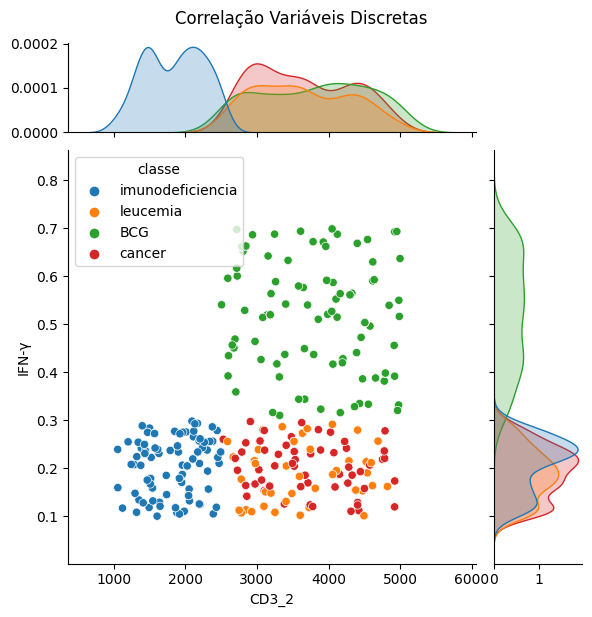

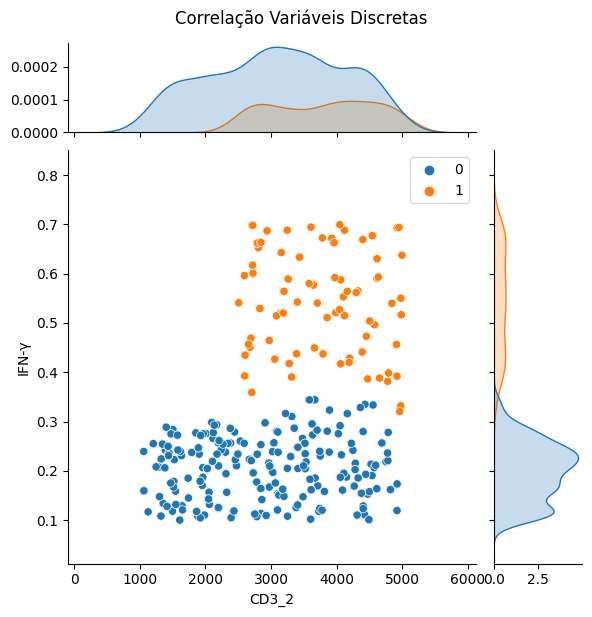

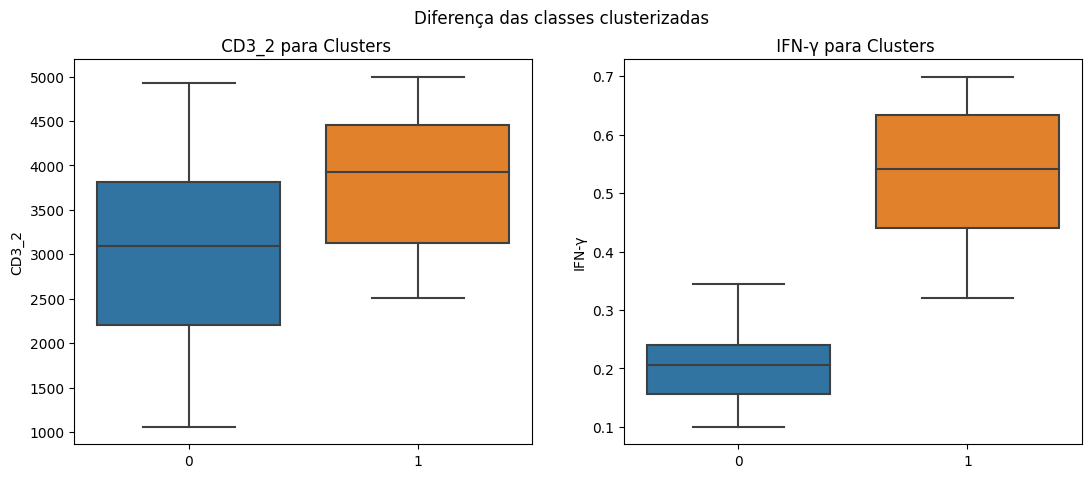

In [41]:
# Analisando os clusters para variável IFN-γ e CD3_2

i = bivariadas[2][0]
j = bivariadas[2][1]
cluster = Clustering(c1=i, c2=j, df=df_train, modelo=nome_modelo)
cluster.cross_validation()

=== MELHOR CONFIGURAÇÃO ENCONTRADA VIA cross_val_score ===
Parâmetros: {'n_clusters': 2, 'metric': 'euclidean', 'linkage': 'ward'}
Silhouette Score Médio (CV): 0.7076

Silhouette Score -> 0.706
Calinski Harabasz Score -> 2202.317
Davies Bouldin Score -> 0.511
Adjusted Rand Score -> 0.346
Adjusted Mutual Info Score -> 0.584


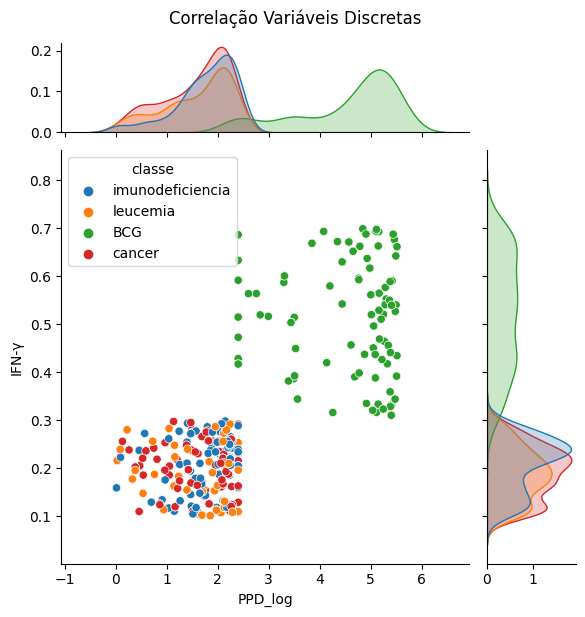

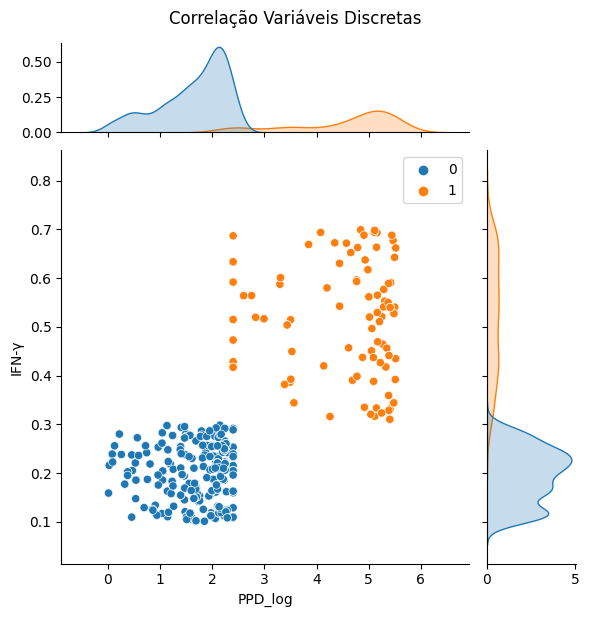

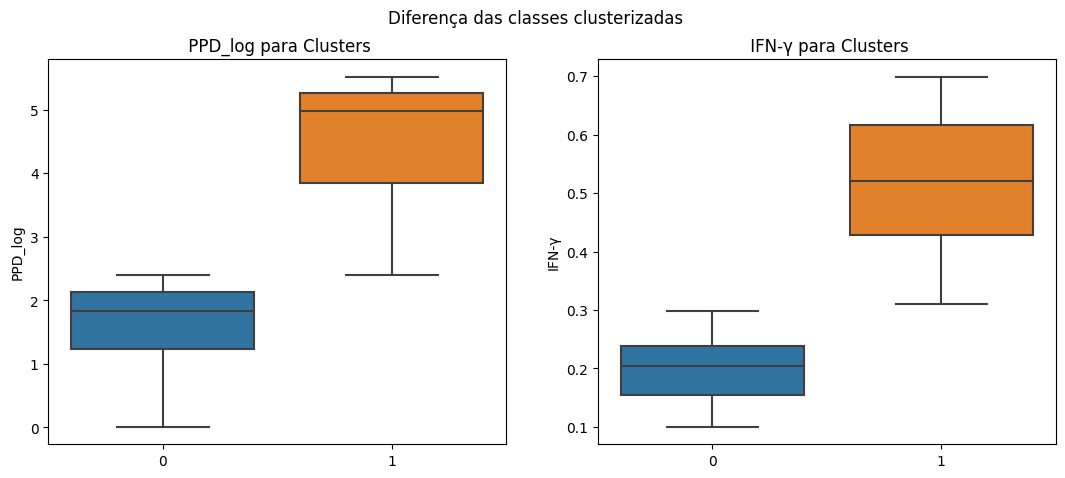

In [42]:
# Analisando os clusters para variável PPD_log e IFN-γ

i = bivariadas[0][0]
j = bivariadas[0][1]
cluster = Clustering(c1=i, c2=j, df=df_train, modelo=nome_modelo)
cluster.cross_validation()

In [43]:
# Repetindo as análises de clustering para a combinação de variáveis
# PPD_log e IFN-γ, 100 vezes, para verificar a estabilidade das métricas
# de avaliação de clustering
data = {}
for i in range(100):
    cluster = Clustering(c1="PPD_log", c2="IFN-γ", df=df_train, modelo=nome_modelo)
    _, metricas = cluster.cross_validation(print_metricas=False)
    data[i] = metricas

df_metricas_repeti = pd.DataFrame(data).T.rename(
    columns={
        0: "Silhouette",
        1: "Calinski Harabasz",
        2: "Davies Bouldin",
        3: "Adjusted Rand",
        4: "Adjusted Mutual Info",
    }
)
df_metricas_repeti.head()

,Silhouette,Calinski Harabasz,Davies Bouldin,Adjusted Rand,Adjusted Mutual Info
0,0.706,2202.317,0.511,0.346,0.584
1,0.706,2202.317,0.511,0.346,0.584
2,0.706,2202.317,0.511,0.346,0.584
3,0.706,2202.317,0.511,0.346,0.584
4,0.706,2202.317,0.511,0.346,0.584


In [44]:
# Analisando as métricas de avaliação de clustering para a combinação
# de variáveis PPD_log e IFN-γ, repetidas 100 vezes
df_metricas_repeti.describe()

,Silhouette,Calinski Harabasz,Davies Bouldin,Adjusted Rand,Adjusted Mutual Info
count,100.000,100.000,1.000000e+02,1.000000e+02,100.000
mean,0.706,2202.317,5.110000e-01,3.460000e-01,0.584
std,0.000,0.000,1.115816e-16,1.115816e-16,0.000
min,0.706,2202.317,5.110000e-01,3.460000e-01,0.584
25%,0.706,2202.317,5.110000e-01,3.460000e-01,0.584
50%,0.706,2202.317,5.110000e-01,3.460000e-01,0.584
75%,0.706,2202.317,5.110000e-01,3.460000e-01,0.584
max,0.706,2202.317,5.110000e-01,3.460000e-01,0.584


### Validação

In [45]:
# Importando os dados de validação
df_valid = pd.concat(
    [
        load("./data/df_estruturada/08_aula_09_X_valid"),
        load("./data/df_estruturada/08_aula_09_y_valid"),
    ],
    axis=1,
)
df_valid.head()

,TP53,IFN-γ,CD3_2,CD8,PPD_log,correlatas,IgM,classe
904,0.205760,0.185144,1735.512581,778.451959,2.228345,0.117692,Baixo,imunodeficiencia
543,0.159611,0.161689,3612.217462,903.493773,2.271285,0.411603,Alto,leucemia
139,0.103551,0.147413,3488.419699,1593.807397,0.532531,0.439125,Alto,cancer
526,0.089775,0.154566,4379.204565,948.954431,1.394407,0.332721,Alto,cancer
868,0.175694,0.205065,3249.381189,1134.132464,0.468055,0.338485,Alto,cancer


In [46]:
# Repetindo as análises de clustering para a combinação de variáveis
# PPD_log e IFN-γ, 100 vezes, para verificar a estabilidade das métricas
# de avaliação de clustering
data = {}
for i in range(100):
    cluster = Clustering(
        c1=bivariadas[0][0], c2=bivariadas[0][1], df=df_valid, modelo=nome_modelo
    )
    _, metricas = cluster.cross_validation(print_metricas=False)
    data[i] = metricas

df_metricas_repeti_valid_agg = pd.DataFrame(data).T.rename(
    columns={
        0: "Silhouette",
        1: "Calinski Harabasz",
        2: "Davies Bouldin",
        3: "Adjusted Rand",
        4: "Adjusted Mutual Info",
    }
)
df_metricas_repeti_valid_agg.head()

,Silhouette,Calinski Harabasz,Davies Bouldin,Adjusted Rand,Adjusted Mutual Info
0,0.712,659.302,0.49,0.356,0.59
1,0.712,659.302,0.49,0.356,0.59
2,0.712,659.302,0.49,0.356,0.59
3,0.712,659.302,0.49,0.356,0.59
4,0.712,659.302,0.49,0.356,0.59


In [47]:
# Analisando as métricas de avaliação de clustering para a combinação
# de variáveis PPD_log e IFN-γ, repetidas 100 vezes
df_metricas_repeti_valid_agg.describe()

,Silhouette,Calinski Harabasz,Davies Bouldin,Adjusted Rand,Adjusted Mutual Info
count,1.000000e+02,100.000,1.000000e+02,1.000000e+02,1.000000e+02
mean,7.120000e-01,659.302,4.900000e-01,3.560000e-01,5.900000e-01
std,1.115816e-16,0.000,2.231632e-16,5.579081e-17,1.115816e-16
min,7.120000e-01,659.302,4.900000e-01,3.560000e-01,5.900000e-01
25%,7.120000e-01,659.302,4.900000e-01,3.560000e-01,5.900000e-01
50%,7.120000e-01,659.302,4.900000e-01,3.560000e-01,5.900000e-01
75%,7.120000e-01,659.302,4.900000e-01,3.560000e-01,5.900000e-01
max,7.120000e-01,659.302,4.900000e-01,3.560000e-01,5.900000e-01


=== MELHOR CONFIGURAÇÃO ENCONTRADA VIA cross_val_score ===
Parâmetros: {'n_clusters': 2, 'metric': 'euclidean', 'linkage': 'average'}
Silhouette Score Médio (CV): 0.4799

Silhouette Score -> 0.486
Calinski Harabasz Score -> 162.881
Davies Bouldin Score -> 0.791
Adjusted Rand Score -> 0.257
Adjusted Mutual Info Score -> 0.453


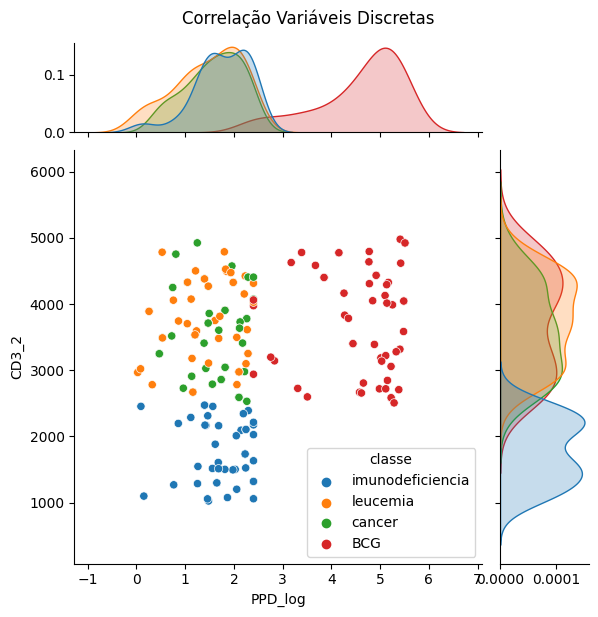

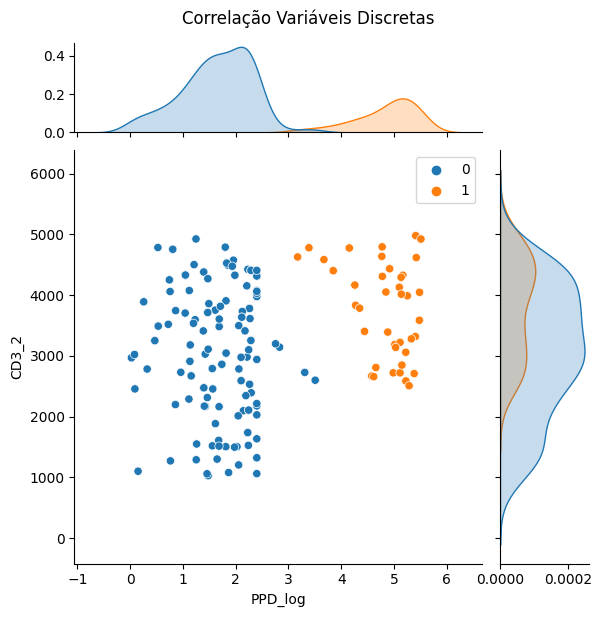

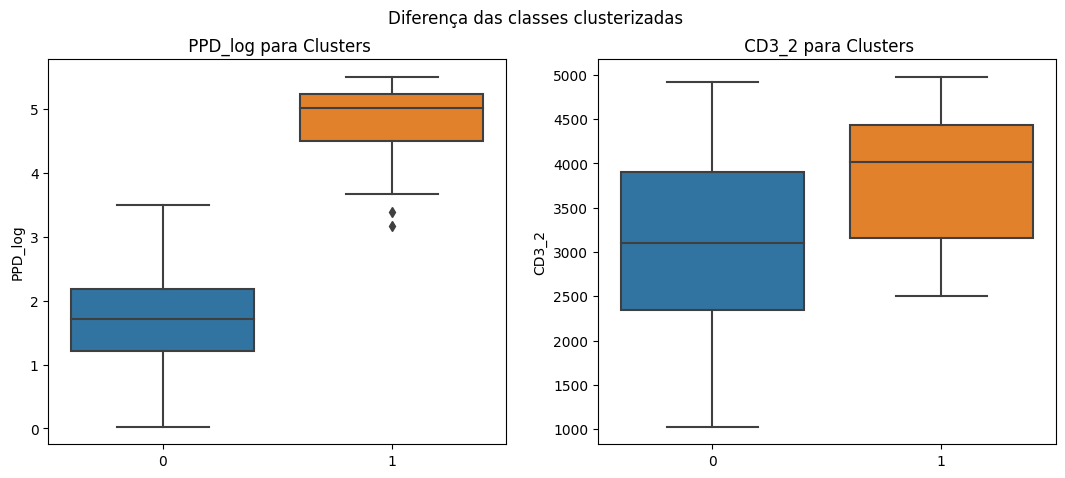

In [48]:
# Analisando os clusters para variável PPD_log e CD3_2

cluster = Clustering(
    c1=bivariadas[1][0], c2=bivariadas[1][1], df=df_valid, modelo=nome_modelo
)
cluster.cross_validation()

=== MELHOR CONFIGURAÇÃO ENCONTRADA VIA cross_val_score ===
Parâmetros: {'n_clusters': 2, 'metric': 'euclidean', 'linkage': 'average'}
Silhouette Score Médio (CV): 0.4768

Silhouette Score -> 0.467
Calinski Harabasz Score -> 128.842
Davies Bouldin Score -> 0.786
Adjusted Rand Score -> 0.128
Adjusted Mutual Info Score -> 0.307


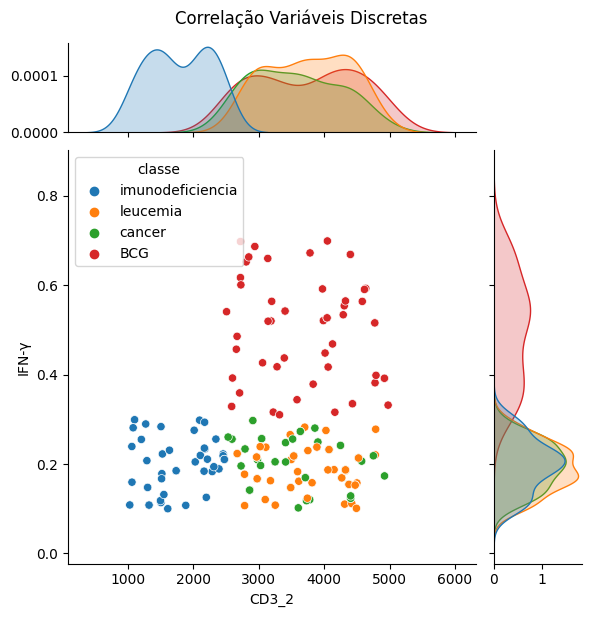

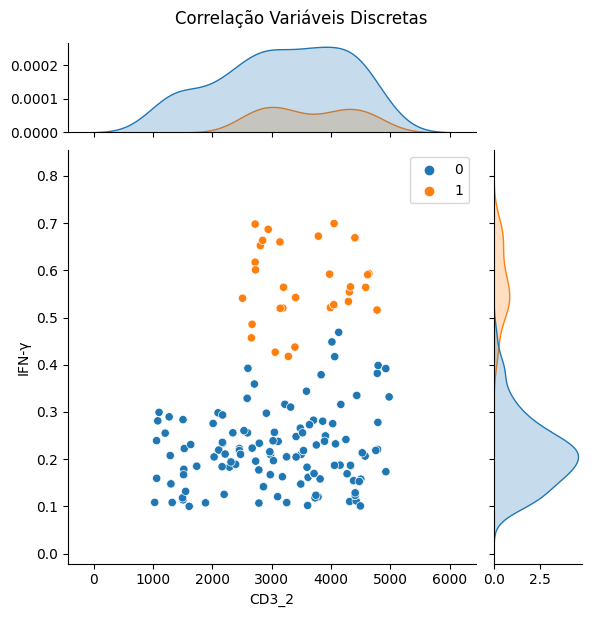

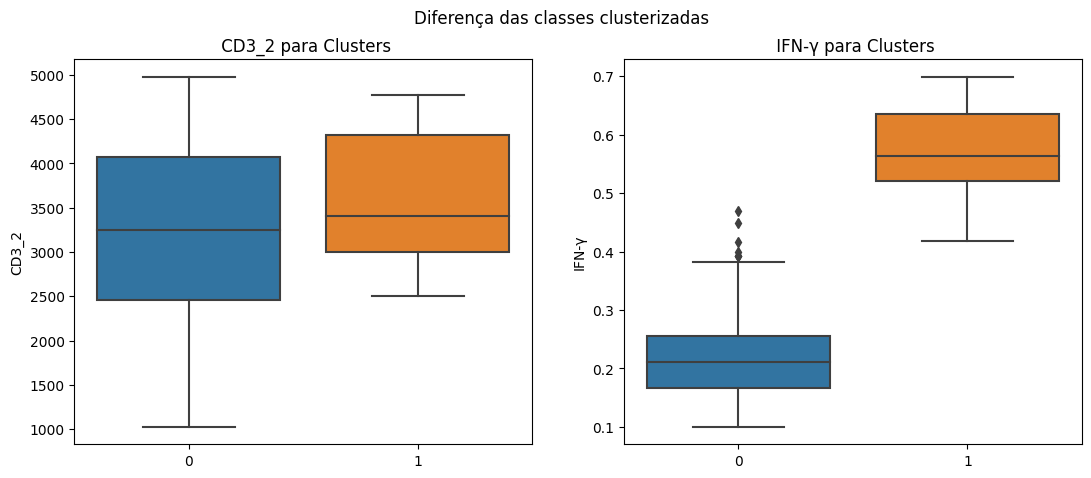

In [49]:
# Analisando os clusters para variável IFN-γ e CD3_2

cluster = Clustering(
    c1=bivariadas[2][0], c2=bivariadas[2][1], df=df_valid, modelo=nome_modelo
)
cluster.cross_validation()

=== MELHOR CONFIGURAÇÃO ENCONTRADA VIA cross_val_score ===
Parâmetros: {'n_clusters': 2, 'metric': 'euclidean', 'linkage': 'ward'}
Silhouette Score Médio (CV): 0.7085

Silhouette Score -> 0.712
Calinski Harabasz Score -> 659.302
Davies Bouldin Score -> 0.49
Adjusted Rand Score -> 0.356
Adjusted Mutual Info Score -> 0.59


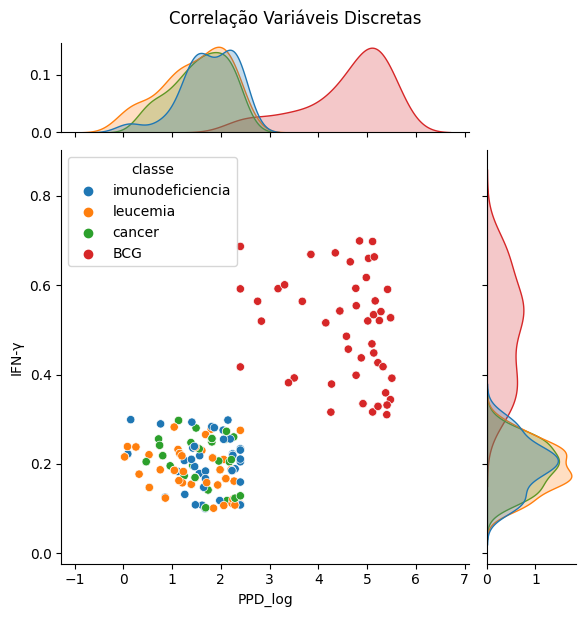

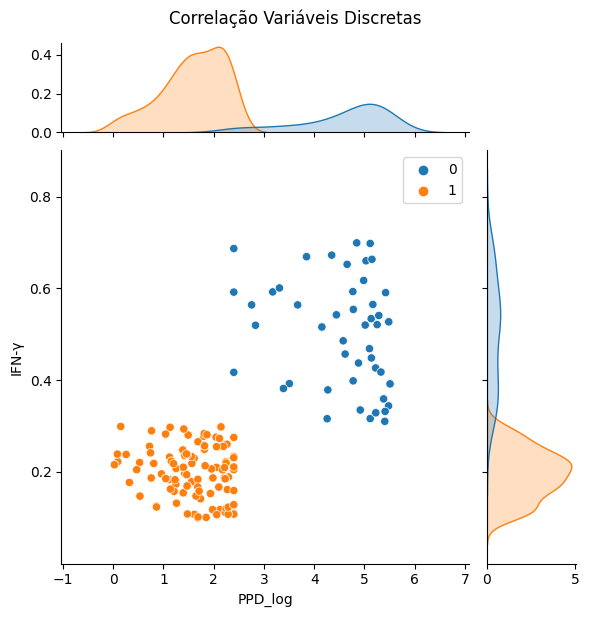

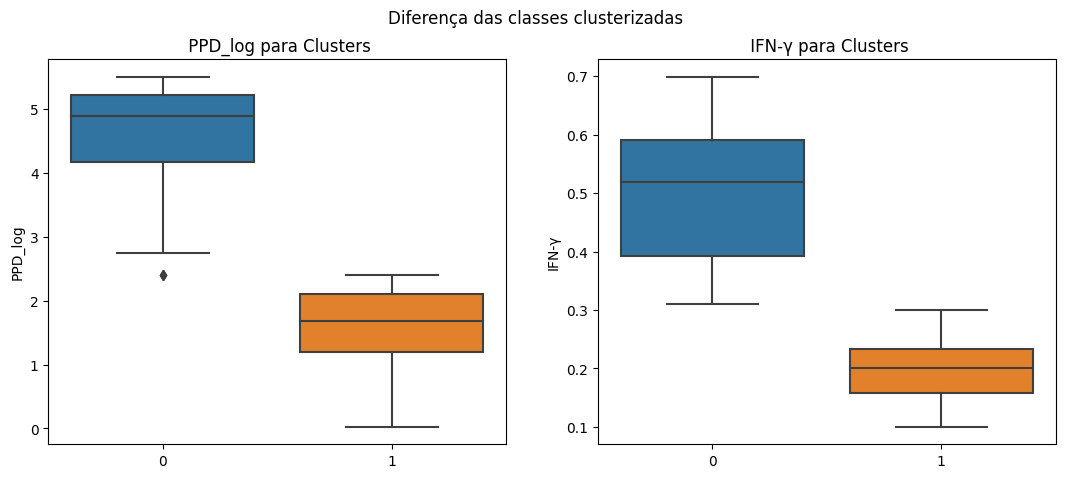

In [50]:
# Analisando os clusters para variável PPD_log e IFN-γ
cluster = Clustering(
    c1=bivariadas[0][0], c2=bivariadas[0][1], df=df_valid, modelo=nome_modelo
)
cluster.cross_validation()

# Analisando métricas validação

In [51]:
# Salvando os dataframes de métricas de avaliação de clustering para cada
# algoritmo

# K-means
local = "./data/08_aula_09_df_metricas_repeti_valid_kmeans"
dump(df_metricas_repeti_valid_kmeans, local)
df_metricas_repeti_valid_kmeans = load(local)
df_metricas_repeti_valid_kmeans["algoritmo"] = "kmeans"
print("K-means")
display(df_metricas_repeti_valid_kmeans.head())

# DBSCAN
local = "./data/08_aula_09_df_metricas_repeti_valid_dbscan"
dump(df_metricas_repeti_valid_dbscan, local)
df_metricas_repeti_valid_dbscan = load(local)
df_metricas_repeti_valid_dbscan["algoritmo"] = "dbscan"
print("DBSCAN")
display(df_metricas_repeti_valid_dbscan.head())

# Agrupamento Hierárquico (Agglomerative)
local = "./data/08_aula_09_df_metricas_repeti_valid_agg"
dump(df_metricas_repeti_valid_agg, local)
df_metricas_repeti_valid_agg = load(local)
df_metricas_repeti_valid_agg["algoritmo"] = "agg"
print("Agglomerative")
display(df_metricas_repeti_valid_agg.head())

K-means


,Silhouette,Calinski Harabasz,Davies Bouldin,Adjusted Rand,Adjusted Mutual Info,algoritmo
0,0.714,660.094,0.484,0.341,0.561,kmeans
1,0.714,660.094,0.484,0.341,0.561,kmeans
2,0.714,660.094,0.484,0.341,0.561,kmeans
3,0.714,660.094,0.484,0.341,0.561,kmeans
4,0.714,660.094,0.484,0.341,0.561,kmeans


DBSCAN


,Silhouette,Calinski Harabasz,Davies Bouldin,Adjusted Rand,Adjusted Mutual Info,algoritmo
0,0.652,429.181,0.931,0.281,0.541,dbscan
1,0.652,429.181,0.931,0.281,0.541,dbscan
2,0.652,429.181,0.931,0.281,0.541,dbscan
3,0.652,429.181,0.931,0.281,0.541,dbscan
4,0.652,429.181,0.931,0.281,0.541,dbscan


Agglomerative


,Silhouette,Calinski Harabasz,Davies Bouldin,Adjusted Rand,Adjusted Mutual Info,algoritmo
0,0.712,659.302,0.49,0.356,0.59,agg
1,0.712,659.302,0.49,0.356,0.59,agg
2,0.712,659.302,0.49,0.356,0.59,agg
3,0.712,659.302,0.49,0.356,0.59,agg
4,0.712,659.302,0.49,0.356,0.59,agg


In [52]:
# Agrupando os resultados das métricas de avaliação de clustering para os
# três algoritmos
df_metricas = pd.concat(
    [
        df_metricas_repeti_valid_kmeans,
        df_metricas_repeti_valid_dbscan,
        df_metricas_repeti_valid_agg,
    ],
    axis=0,
)
df_metricas.head()

,Silhouette,Calinski Harabasz,Davies Bouldin,Adjusted Rand,Adjusted Mutual Info,algoritmo
0,0.714,660.094,0.484,0.341,0.561,kmeans
1,0.714,660.094,0.484,0.341,0.561,kmeans
2,0.714,660.094,0.484,0.341,0.561,kmeans
3,0.714,660.094,0.484,0.341,0.561,kmeans
4,0.714,660.094,0.484,0.341,0.561,kmeans


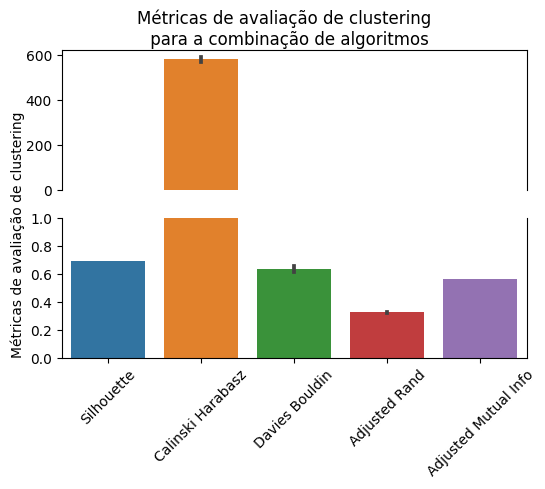

In [53]:
# Gráfico comparativo das métricas de avaliação de clustering para os três
# algoritmos
fig, ax = plt.subplots(2, 1, figsize=(6, 4))

plt.suptitle("Métricas de avaliação de clustering \n para a combinação de algoritmos")

p = sns.barplot(df_metricas, ax=ax[0])
plt.xticks(rotation=45)
plt.ylim(100, 700)
p.set(xlabel=None)
p.set_xticks([])
p.spines["bottom"].set_visible(False)

q = sns.barplot(df_metricas, ax=ax[1])
plt.xticks(rotation=45)
plt.ylim(0, 1)
q.spines["top"].set_visible(False)

plt.ylabel("Métricas de avaliação de clustering", loc="bottom")

plt.show()

In [54]:
# Agrupando os resultados das métricas de avaliação de clustering para os três
# algoritmos, com multi-index
df_metricas = pd.concat(
    [
        df_metricas_repeti_valid_kmeans,
        df_metricas_repeti_valid_dbscan,
        df_metricas_repeti_valid_agg,
    ],
    axis=1,
    keys=["kmeans", "dbscan", "agglomerative"],
)
df_metricas.head()

kmeans                                                 \
  Silhouette Calinski Harabasz Davies Bouldin Adjusted Rand   
0      0.714           660.094          0.484         0.341   
1      0.714           660.094          0.484         0.341   
2      0.714           660.094          0.484         0.341   
3      0.714           660.094          0.484         0.341   
4      0.714           660.094          0.484         0.341   

                                     dbscan                                   \
  Adjusted Mutual Info algoritmo Silhouette Calinski Harabasz Davies Bouldin   
0                0.561    kmeans      0.652           429.181          0.931   
1                0.561    kmeans      0.652           429.181          0.931   
2                0.561    kmeans      0.652           429.181          0.931   
3                0.561    kmeans      0.652           429.181          0.931   
4                0.561    kmeans      0.652           429.181          0.931   

                                               agglomerative  \
  Adjusted Rand Adjusted Mutual Info algoritmo    Silhouette   
0         0.281                0.541    dbscan         0.712   
1         0.281                0.541    dbscan         0.712   
2         0.281                0.541    dbscan         0.712   
3         0.281                0.541    dbscan         0.712   
4         0.281                0.541    dbscan         0.712   

                                                                       \
  Calinski Harabasz Davies Bouldin Adjusted Rand Adjusted Mutual Info   
0           659.302           0.49         0.356                 0.59   
1           659.302           0.49         0.356                 0.59   
2           659.302           0.49         0.356                 0.59   
3           659.302           0.49         0.356                 0.59   
4           659.302           0.49         0.356                 0.59   

             
  algoritmo  
0       agg  
1       agg  
2       agg  
3       agg  
4       agg

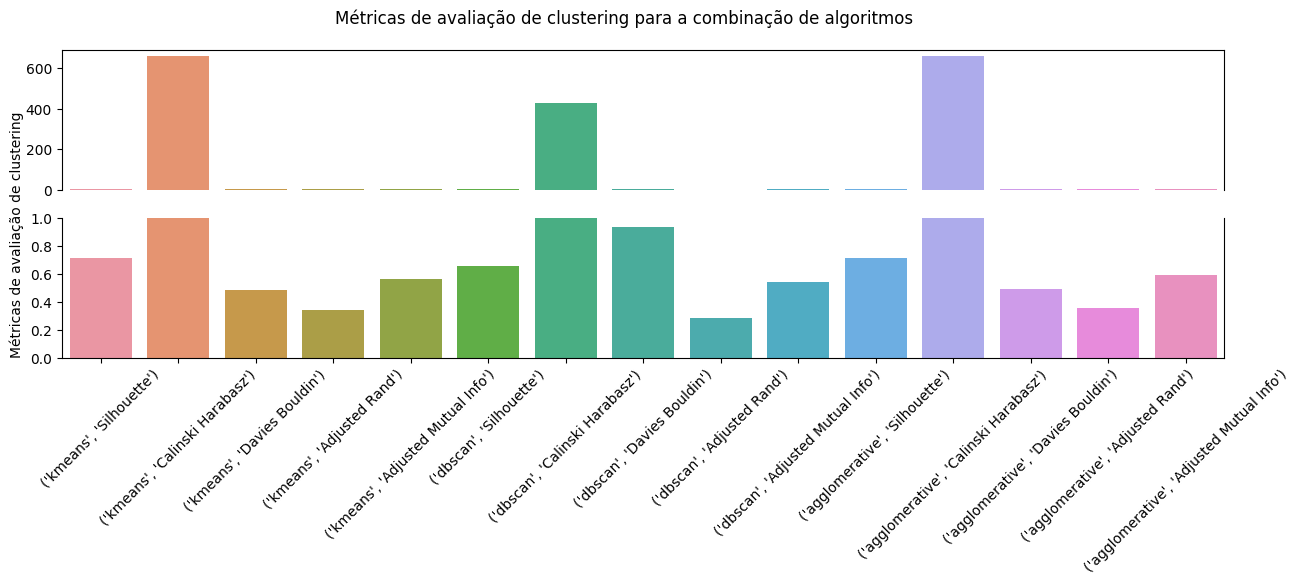

In [55]:
# Gráfico comparativo das métricas de avaliação de clustering para os três
# algoritmos, com multi-index
fig, ax = plt.subplots(2, 1, figsize=(15, 4))
plt.suptitle("Métricas de avaliação de clustering para a combinação de algoritmos")

p = sns.barplot(df_metricas, ax=ax[0])
plt.xticks(rotation=45)
plt.ylim(100, 700)
p.set(xlabel=None)
p.set_xticks([])
p.spines["bottom"].set_visible(False)

q = sns.barplot(df_metricas, ax=ax[1])
plt.xticks(rotation=45)
plt.ylim(0, 1)
q.spines["top"].set_visible(False)
plt.ylabel("Métricas de avaliação de clustering", loc="bottom")

plt.show()

In [56]:
def editar_df(df: pd.DataFrame, modelo: str) -> pd.DataFrame:
    """
    Função para editar o dataframe de métricas de avaliação de clustering
    para cada algoritmo, de forma a facilitar a análise comparativa entre
    eles.
        Parametros:
        -----------
            df: pd.DataFrame
                Dataframe de métricas de avaliação de clustering para
                cada algoritmo.
            modelo: str
                Nome do algoritmo de clustering.
        Retorna:
            pd.DataFrame
    """
    colunas = {0: "valores", "index": "metricas"}
    retorno = (
        df.select_dtypes(include="number")
        .median()
        .to_frame()
        .reset_index()
        .rename(columns=colunas)
        .assign(modelo=modelo)
    )
    return retorno

In [57]:
# Agrupando os resultados das métricas de avaliação de clustering para os três
# algoritmos, com multi-index, e calculando a mediana das métricas

df_metricas = pd.concat(
    (
        editar_df(df=df_metricas_repeti_valid_kmeans, modelo="K-means"),
        editar_df(df=df_metricas_repeti_valid_dbscan, modelo="DBSCAN"),
        editar_df(df=df_metricas_repeti_valid_agg, modelo="Agglomerative"),
    )
)
df_metricas

,metricas,valores,modelo
0,Silhouette,0.714,K-means
1,Calinski Harabasz,660.094,K-means
2,Davies Bouldin,0.484,K-means
3,Adjusted Rand,0.341,K-means
4,Adjusted Mutual Info,0.561,K-means
0,Silhouette,0.652,DBSCAN
1,Calinski Harabasz,429.181,DBSCAN
2,Davies Bouldin,0.931,DBSCAN
3,Adjusted Rand,0.281,DBSCAN
4,Adjusted Mutual Info,0.541,DBSCAN


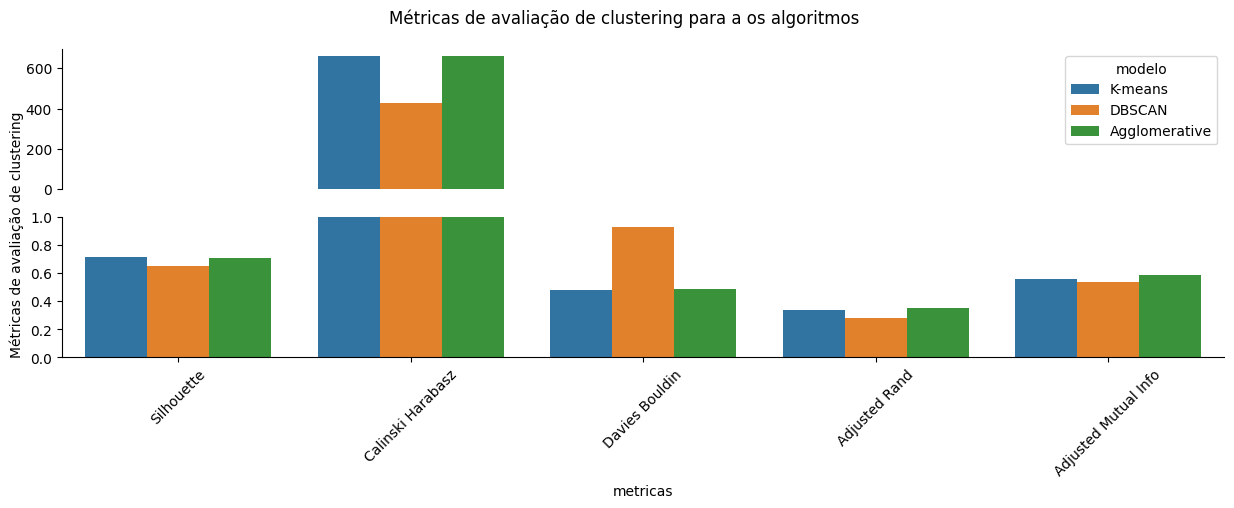

In [58]:
# Grafico comparativo das métricas de avaliação de clustering para os três
# algoritmos, com multi-index, e calculando a mediana das métricas
fig, ax = plt.subplots(2, 1, figsize=(15, 4))
plt.suptitle("Métricas de avaliação de clustering para a os algoritmos")
p = sns.barplot(x="metricas", y="valores", hue="modelo", data=df_metricas, ax=ax[0])
plt.xticks(rotation=45)
plt.ylim(100, 700)
p.set(xlabel=None, ylabel=None)
p.set_xticks([])
p.spines["bottom"].set_visible(False)
p.spines[["top", "right"]].set_visible(False)

q = sns.barplot(x="metricas", y="valores", hue="modelo", data=df_metricas, ax=ax[1])
plt.xticks(rotation=45)
plt.ylim(0, 1)
q.get_legend().remove()
q.spines[["top", "right"]].set_visible(False)
plt.ylabel("Métricas de avaliação de clustering", loc="bottom")

plt.show()

# Testes

__Teste Qui-Quadrado de Aderência/Independência__:
- Teste de Proporções dos Clusters: Avalia se a distribuição de frequência de pontos por cluster é idêntica entre treino (700) e validação (100).

__Adjusted Rand Index__:
- Avaliação da Estrutura de Rotulagem (Cross-Prediction ou Teste de Permutação): Avalia se o modelo fitado no treino atribui aos dados de validação os mesmos rótulos que um modelo fitado diretamente na validação atribuiria.

|Hipótese|Interpretação|
|-|-|
|H0 - Hipótese Nula|A distribuição de clusters na teste é igual à do treino. O modelo generalizou bem.|
H1 - Hipótese Alternativa|A distribuição de clusters na teste é diferente da do treino. Houve data drift ou mudança de padrão.|

In [59]:
from scipy.stats import chisquare
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.neighbors import KNeighborsClassifier, NearestCentroid
from sklearn.metrics import adjusted_rand_score

## Importando dados de validação

In [60]:
# Importando os dados de treino
df_test = pd.concat(
    [
        load("./data/df_estruturada/08_aula_09_X_test"),
        load("./data/df_estruturada/08_aula_09_y_test"),
    ],
    axis=1,
)
df_test.head()

,TP53,IFN-γ,CD3_2,CD8,PPD_log,correlatas,IgM,classe
557,0.221689,0.237781,3107.839710,1065.934040,1.478703,0.419394,Alto,cancer
798,0.038133,0.239653,3744.296122,1055.014527,1.406982,0.337995,Alto,leucemia
977,0.233695,0.273088,3635.413739,1341.790170,2.114693,0.402492,Alto,cancer
136,0.247209,0.204334,3521.196455,1420.417680,1.050797,0.404243,Alto,cancer
575,0.040772,0.298275,2094.453959,537.993685,2.145163,0.134077,Baixo,imunodeficiencia


In [61]:
# Retornaod dados de treino
df_train.head()

,TP53,IFN-γ,CD3_2,CD8,PPD_log,correlatas,IgM,classe
541,0.060824,0.156681,2054.750574,416.256426,1.728509,0.274165,Baixo,imunodeficiencia
440,0.049927,0.277029,1853.437984,561.318387,1.240507,0.222972,Baixo,imunodeficiencia
482,0.020794,0.169621,3712.239299,1314.103239,1.470395,0.468595,Alto,leucemia
422,0.098734,0.117708,1864.705992,802.282545,1.574182,0.288605,Baixo,imunodeficiencia
778,0.193195,0.109547,2926.017038,1524.468444,2.400111,0.466135,Alto,leucemia


## K-means

In [62]:
bivariadas = [
    ["PPD_log", "IFN-γ"],
    ["PPD_log", "CD3_2"],
    ["CD3_2", "IFN-γ"],
]
ut.printLis(bivariadas)

-------------
-=< Lista >=-
-------------
0 -> ['PPD_log', 'IFN-γ']
1 -> ['PPD_log', 'CD3_2']
2 -> ['CD3_2', 'IFN-γ']


In [63]:
# Testando os modelos de clustering via K-means
resultados = {}
for bivaria in bivariadas:
    i = bivaria[0]
    j = bivaria[1]
    print(i, j, "-" * 100)

    cluster = Clustering(c1=i, c2=j, df=df_train, modelo="kmeans")
    resultados[f"K-means: {i}/{j}"] = cluster.testar_modelo(
        best_param={"n_clusters": 3, "init": "k-means++", "n_init": 10},
        df_test=df_test,
    )

PPD_log IFN-γ ----------------------------------------------------------------------------------------------------
 RESULTADOS DA ANÁLISE DE COMPARAÇÃO DE CLUSTERS
Frequências Esperadas na Validação (Treino): 
[26.57142857 19.71428571 53.71428571]
Frequências Observadas na Validação:
       [28 23 49]
--------------------------------------------------
Estatística Qui-Quadrado (χ²): 1.0382
p-valor:                        0.5951
--------------------------------------------------
Conclusão: Não rejeitamos H0. A distribuição dos clusters na validação É IGUAL à do treino (p > 0.05).
--------------------------------------------------
Adjusted Rand Index (ARI) entre modelo de Treino e modelo da Validação: 0.9343 (ARI próximo de 1.0 indica que a partição geométrica gerada é virtualmente idêntica)
PPD_log CD3_2 ----------------------------------------------------------------------------------------------------
 RESULTADOS DA ANÁLISE DE COMPARAÇÃO DE CLUSTERS
Frequências Esperadas na Validação (

## DBSCAN

In [64]:
# Testando os modelos de clustering via DBSCAN
for bivaria in bivariadas:
    i = bivaria[0]
    j = bivaria[1]
    print(i, j, "-" * 100)

    cluster = Clustering(c1=i, c2=j, df=df_train, modelo="dbscan")
    resultados[f"DBSCAN: {i}/{j}"] = cluster.testar_modelo(
        best_param={"eps": 0.5, "min_samples": 10, "metric": "euclidean"},
        df_test=df_test,
    )

PPD_log IFN-γ ----------------------------------------------------------------------------------------------------
 RESULTADOS DA COMPARAÇÃO DE CLUSTERS (DBSCAN)
Clusters identificados no Treino:       
[0]
Frequências Esperadas na Validação:     
[100.]
Frequências Observadas na Validação:    
[100]
-------------------------------------------------------
Estatística Qui-Quadrado (χ²): 0.0000
p-valor:                        nan
-------------------------------------------------------
Conclusão: Rejeitamos H0. A distribuição dos clusters na validação É DIFERENTE da do treino  (p <= 0.05).
-------------------------------------------------------
Adjusted Rand Index (ARI) entre predição e DBSCAN direto na Validação: 0.0000
PPD_log CD3_2 ----------------------------------------------------------------------------------------------------
 RESULTADOS DA COMPARAÇÃO DE CLUSTERS (DBSCAN)
Clusters identificados no Treino:       
[-1]
Frequências Esperadas na Validação:     
[100.]
Frequências Obse

## Agrupamento Hierarquico

In [65]:
# Testando os modelos de clustering via Agrupamento Hierarquico
for bivaria in bivariadas:
    i = bivaria[0]
    j = bivaria[1]
    print(i, j, "-" * 100)

    cluster = Clustering(c1=i, c2=j, df=df_train, modelo="agglomerative")
    resultados[f"Agg: {i}/{j}"] = cluster.testar_modelo(
        best_param={"n_clusters": 2, "metric": "euclidean", "linkage": "average"},
        df_test=df_test,
    )

PPD_log IFN-γ ----------------------------------------------------------------------------------------------------
 RESULTADOS DA COMPARAÇÃO (AGGLOMERATIVE CLUSTERING)
Clusters no Treino:                  
[0 1]
Frequências Esperadas na Validação:  
[77.43 22.57]
Frequências Observadas na Validação:  
[73 27]
------------------------------------------------------------
Estatística Qui-Quadrado (χ²): 1.1222
p-valor:                        0.2894
------------------------------------------------------------
Conclusão: Não rejeitamos H0. A distribuição dos clusters na validação É IGUAL à do treino (p > 0.05).
------------------------------------------------------------
Adjusted Rand Index (ARI) entre projeção e agrupamento direto: 0.8353
PPD_log CD3_2 ----------------------------------------------------------------------------------------------------
 RESULTADOS DA COMPARAÇÃO (AGGLOMERATIVE CLUSTERING)
Clusters no Treino:                  
[0 1]
Frequências Esperadas na Validação:  
[75.29

## Resultado Final

In [66]:
ut.printDic(resultados)

------------------
-=< Dicionário >=-
------------------
K-means: PPD_log/IFN-γ -> True
K-means: PPD_log/CD3_2 -> True
K-means: CD3_2/IFN-γ -> True
DBSCAN: PPD_log/IFN-γ -> False
DBSCAN: PPD_log/CD3_2 -> False
DBSCAN: CD3_2/IFN-γ -> False
Agg: PPD_log/IFN-γ -> True
Agg: PPD_log/CD3_2 -> False
Agg: CD3_2/IFN-γ -> False
